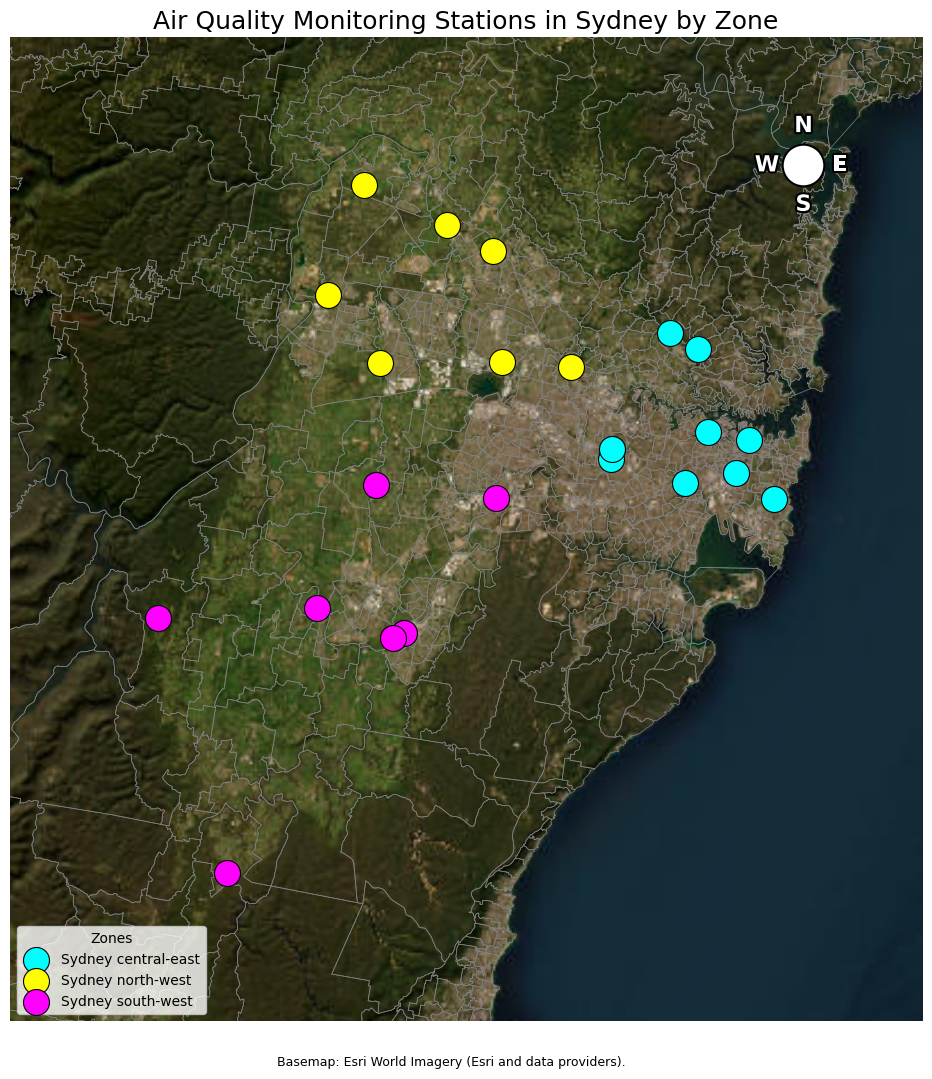

In [10]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import box
import matplotlib.patheffects as patheffects

# === Define the compass function ===
def add_compass_with_dot(ax, x=0.87, y=0.87, size=16, pad=0.04,
                          color='white', outline_color='black', dot_size=30):
    ax.annotate('N', xy=(x, y + pad), xycoords='axes fraction',
                ha='center', va='center', fontsize=size, color=color, weight='bold',
                path_effects=[patheffects.withStroke(linewidth=3, foreground=outline_color)])
    ax.annotate('S', xy=(x, y - pad), xycoords='axes fraction',
                ha='center', va='center', fontsize=size, color=color, weight='bold',
                path_effects=[patheffects.withStroke(linewidth=3, foreground=outline_color)])
    ax.annotate('E', xy=(x + pad, y), xycoords='axes fraction',
                ha='center', va='center', fontsize=size, color=color, weight='bold',
                path_effects=[patheffects.withStroke(linewidth=3, foreground=outline_color)])
    ax.annotate('W', xy=(x - pad, y), xycoords='axes fraction',
                ha='center', va='center', fontsize=size, color=color, weight='bold',
                path_effects=[patheffects.withStroke(linewidth=3, foreground=outline_color)])
    ax.plot(x, y, 'o', transform=ax.transAxes, markersize=dot_size, color=color,
            markeredgecolor=outline_color, markeredgewidth=1.5)

# === NEW: helper to remove attribution text drawn on the axes ===
def remove_basemap_attribution(ax, keywords=("Esri", "OpenStreetMap", "USGS", "Microsoft", "Here", "TomTom", "NASA")):
    """
    Contextily often adds attribution as ax.text objects.
    This removes those text objects from inside the map area.
    """
    for t in list(ax.texts):
        txt = (t.get_text() or "")
        if any(k in txt for k in keywords):
            t.remove()

# === 0. Helper: classify stations into zones ===
def classify_zone(station_name: str) -> str:
    if pd.isna(station_name):
        return "Other / Unspecified"
    name = station_name.strip().upper()

    central_east = {
        "ALEXANDRIA","COOK AND PHILLIP","CHULLORA","EARLWOOD","LIDCOMBE",
        "LINDFIELD","MACQUARIE PARK","RANDWICK","ROZELLE","ULTIMO-UTS",
    }
    north_west = {"PARRAMATTA NORTH","PENRITH","PROSPECT","RICHMOND","ROUSE HILL","ST MARYS","VINEYARD"}
    south_west = {"BARGO","BRINGELLY","CAMDEN","CAMPBELLTOWN WEST","LIVERPOOL","MACARTHUR","OAKDALE"}

    if name in central_east:
        return "Sydney central-east"
    elif name in north_west:
        return "Sydney north-west"
    elif name in south_west:
        return "Sydney south-west"
    else:
        return "Other / Unspecified"

# === 1. Load AQ station CSV ===
csv_path = r"C:\Users\smkasimongwa\OneDrive - The University of Melbourne\Desktop\Research FIles\population exposure\Sydney_ Air Quality Stations.csv"
stations_df = pd.read_csv(csv_path)

candidate_cols = [col for col in stations_df.columns if any(key in col.lower() for key in ["name", "site", "station"])]
if not candidate_cols:
    raise ValueError("Could not automatically find a station name column.")
station_name_col = candidate_cols[0]

stations_df["Zone"] = stations_df[station_name_col].apply(classify_zone)

stations_gdf = gpd.GeoDataFrame(
    stations_df,
    geometry=gpd.points_from_xy(stations_df["longitude"], stations_df["latitude"]),
    crs="EPSG:4326"
)

# === 2. Load NSW Localities shapefile ===
shapefile_path = r"C:\Users\smkasimongwa\OneDrive - The University of Melbourne\Desktop\Research FIles\population exposure\gda2020\GDA2020\nsw_localities.shp"
nsw_gdf = gpd.read_file(shapefile_path)

stations_gdf = stations_gdf.to_crs(epsg=3857)
nsw_gdf = nsw_gdf.to_crs(epsg=3857)

# === 3. Get extent around AQ stations for zooming ===
minx, miny, maxx, maxy = stations_gdf.total_bounds
buffer = 20000
sydney_extent = (minx - buffer, miny - buffer, maxx + buffer, maxy + buffer)

sydney_box = box(*sydney_extent)
sydney_localities = nsw_gdf[nsw_gdf.intersects(sydney_box)]

# === 4. Plot map ===
fig, ax = plt.subplots(figsize=(12, 12))

sydney_localities.plot(ax=ax, facecolor='none', edgecolor='gray', linewidth=0.5)

# Basemap
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)

# ✅ Remove the tiny attribution that appears inside the map
remove_basemap_attribution(ax)

# ✅ Add a clean attribution outside the map area (bottom center)
# (You can also move this to your thesis figure caption if you prefer.)
fig.text(
    0.5, 0.02,
    "Basemap: Esri World Imagery (Esri and data providers).",
    ha="center", va="bottom", fontsize=9
)

zone_colors = {
    "Sydney central-east": "cyan",
    "Sydney north-west": "yellow",
    "Sydney south-west": "magenta",
    "Other / Unspecified": "white",
}

for zone, color in zone_colors.items():
    subset = stations_gdf[stations_gdf["Zone"] == zone]
    if subset.empty:
        continue
    subset.plot(
        ax=ax, color=color, markersize=350,
        edgecolor='black', linewidth=0.8, label=zone
    )

ax.set_xlim(sydney_extent[0], sydney_extent[2])
ax.set_ylim(sydney_extent[1], sydney_extent[3])

add_compass_with_dot(ax, x=0.87, y=0.87, size=16, pad=0.04,
                     color='white', outline_color='black', dot_size=30)

ax.set_title("Air Quality Monitoring Stations in Sydney by Zone", fontsize=18)
ax.axis('off')
plt.legend(title="Zones", loc="lower left")

# ✅ Make space for the bottom caption so it doesn’t overlap
plt.subplots_adjust(bottom=0.06)

plt.show()


C:\Users\smkasimongwa\AppData\Local\Temp\ipykernel_27940\1087963712.py:85: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  t_parsed = pd.to_datetime(time_fixed, errors="coerce")


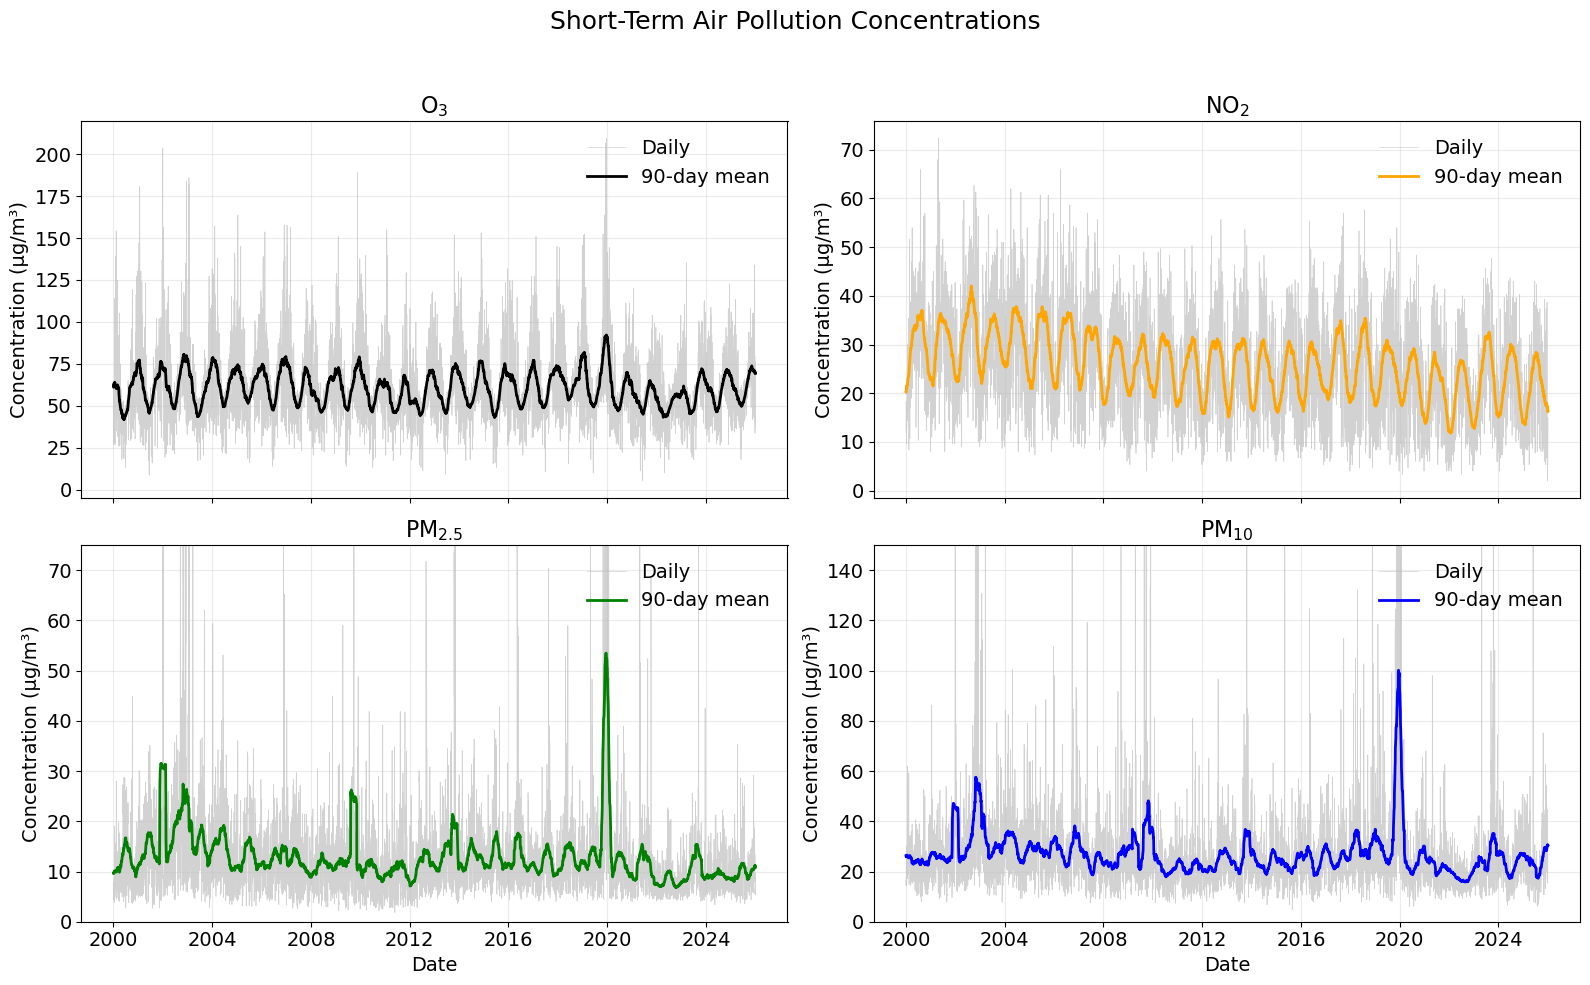

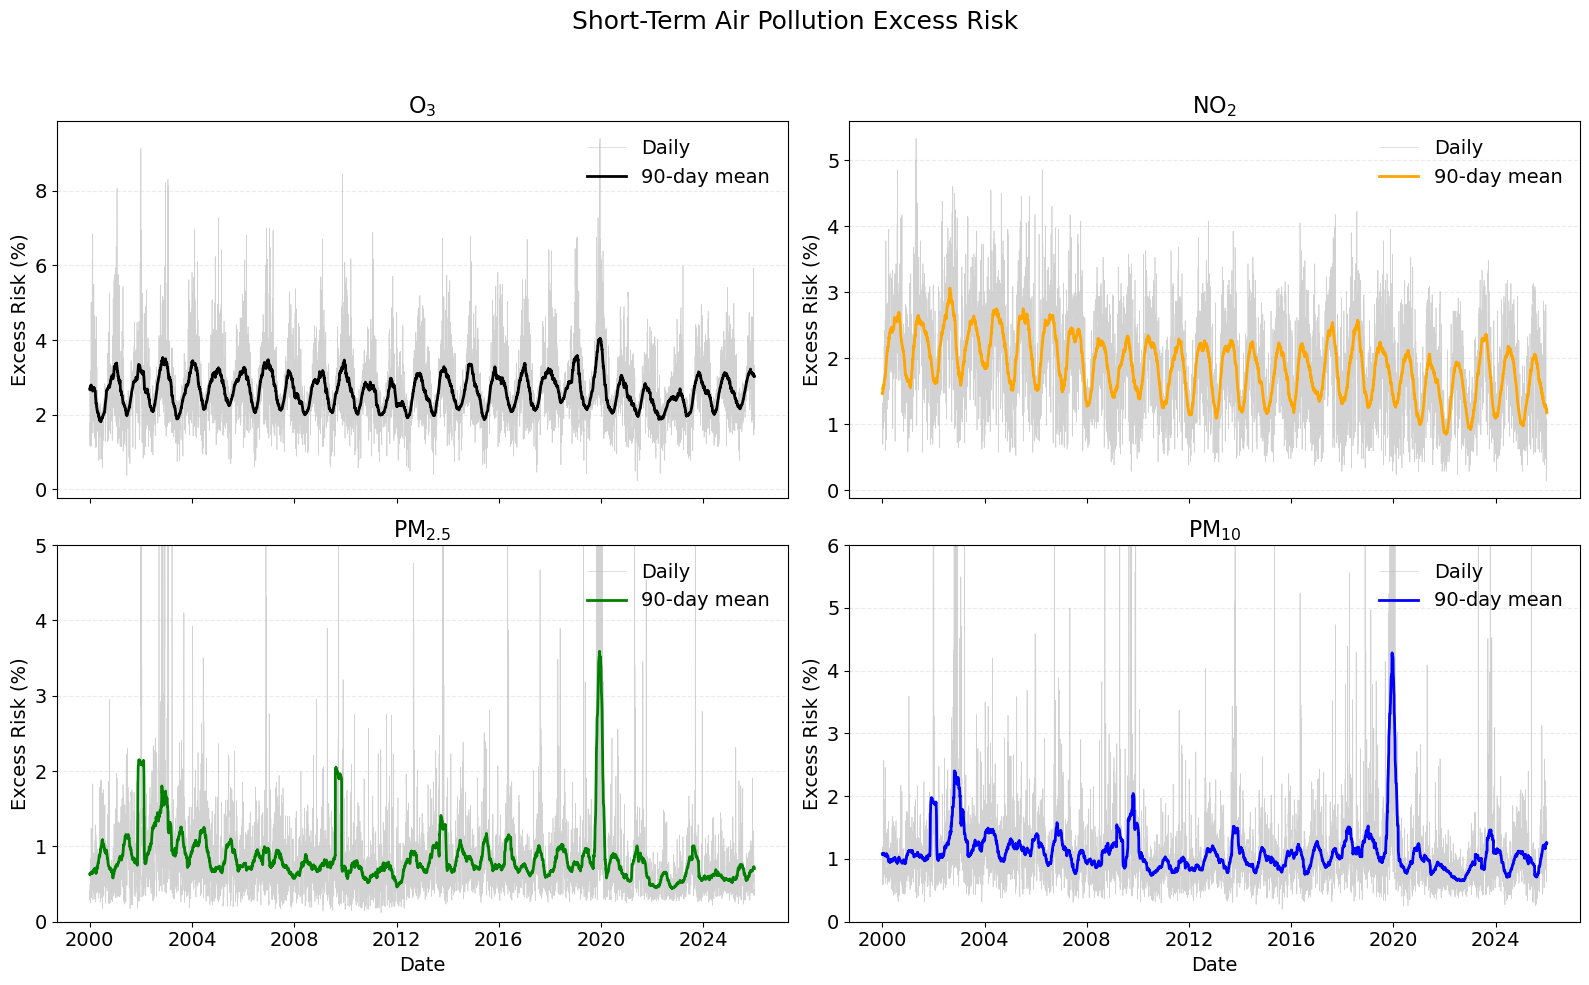

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 0) INPUT / OUTPUT PATHS — GitHub-ready relative paths
# ============================================================

PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

FIGURES_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

file_path = DATA_DIR / "Sydney_Hourly_Dataset.csv"

daily_outfile = OUTPUTS_DIR / "Sydney_Daily3hrMax_with_ER.csv"
figA_file = FIGURES_DIR / "Sydney_Daily3hrMax_Concentration_2x2.png"
figB_file = FIGURES_DIR / "Sydney_Daily3hrMax_ExcessRisk_2x2.png"

# ============================================================
# 1) SETTINGS
# ============================================================

COL_DATE = "Date"
COL_TIME = "Time"
POLLUTANTS = ["O3", "NO2", "PM2.5", "PM10"]

DAYFIRST = True
ROLLING_DAYS_FOR_PLOT = 90
CENTER_ROLLING = True

COLORS = {
    "O3": "black",
    "PM10": "blue",
    "NO2": "orange",
    "PM2.5": "green",
}

UNITS = {p: "µg/m³" for p in POLLUTANTS}

LABELS = {
    "O3": r"O$_3$",
    "NO2": r"NO$_2$",
    "PM2.5": r"PM$_{2.5}$",
    "PM10": r"PM$_{10}$",
}

# ============================================================
# 2) ORELLANO et al. (2020) — RR per 10 units
# ============================================================

RR10 = {
    "PM2.5": 1.0065,
    "PM10":  1.0041,
    "NO2":   1.0072,
    "O3":    1.0043,
}

LN_RR10 = {k: np.log(v) for k, v in RR10.items()}

# ============================================================
# 3) HELPERS
# ============================================================

def er_percent_from_rr10(conc: pd.Series, ln_rr10: float) -> pd.Series:
    c = pd.to_numeric(conc, errors="coerce")
    rr_c = np.exp(ln_rr10 * (c / 10.0))
    return (rr_c - 1.0) * 100.0


def build_datetime(df: pd.DataFrame, date_col: str, time_col: str, dayfirst: bool = True) -> pd.Series:
    date_str = df[date_col].astype(str).str.strip()
    time_str = df[time_col].astype(str).str.strip()

    date = pd.to_datetime(date_str, errors="coerce", dayfirst=dayfirst)

    is_24 = time_str.str.match(r"^24:\d{2}(:\d{2})?$")
    time_fixed = time_str.where(~is_24, time_str.str.replace(r"^24:", "00:", regex=True))

    t_parsed = pd.to_datetime(time_fixed, errors="coerce")

    td = (
        pd.to_timedelta(t_parsed.dt.hour, unit="h")
        + pd.to_timedelta(t_parsed.dt.minute, unit="m")
        + pd.to_timedelta(t_parsed.dt.second, unit="s")
    )

    dt = date + td + pd.to_timedelta(is_24.astype(int), unit="D")
    return dt


def get_subplot_position(i):
    return divmod(i, 2)

# ============================================================
# 4) DATA PROCESSING
# ============================================================

df = pd.read_csv(file_path)

df.columns = [c.strip() for c in df.columns]

df["datetime"] = build_datetime(df, COL_DATE, COL_TIME, dayfirst=DAYFIRST)

df = df.sort_values("datetime").set_index("datetime")

for p in POLLUTANTS:
    df[p] = pd.to_numeric(df[p], errors="coerce")

df_3hr = df[POLLUTANTS].rolling(window=3, min_periods=3).mean()

daily_3hr_max = df_3hr.resample("D").max()

daily_3hr_max = daily_3hr_max.rename(
    columns={p: f"{p}_3hrAvgMax" for p in POLLUTANTS}
)

for p in POLLUTANTS:
    daily_3hr_max[f"{p}_%ER"] = er_percent_from_rr10(
        daily_3hr_max[f"{p}_3hrAvgMax"],
        LN_RR10[p]
    )

daily_3hr_max.reset_index().rename(columns={"datetime": "Date"}).to_csv(
    daily_outfile,
    index=False
)

# ============================================================
# 5A) FIGURE A — CONCENTRATION
# ============================================================

figA, axesA = plt.subplots(nrows=2, ncols=2, figsize=(16, 10), sharex=True)
figA.suptitle("Short-Term Air Pollution Concentrations", fontsize=18, y=0.98)

for i, p in enumerate(POLLUTANTS):
    row, col = get_subplot_position(i)
    ax = axesA[row, col]

    conc = daily_3hr_max[f"{p}_3hrAvgMax"]
    conc_roll = conc.rolling(
        window=ROLLING_DAYS_FOR_PLOT,
        min_periods=1,
        center=CENTER_ROLLING
    ).mean()

    ax.plot(conc.index, conc.values, color="0.75", linewidth=0.5, alpha=0.7, label="Daily")
    ax.plot(conc_roll.index, conc_roll.values, color=COLORS[p], linewidth=2.0, label=f"{ROLLING_DAYS_FOR_PLOT}-day mean")

    ax.set_title(LABELS[p], fontsize=16)
    ax.set_ylabel(f"Concentration ({UNITS[p]})", fontsize=14)
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(True, alpha=0.25)

    if p == "PM2.5":
        ax.set_ylim(0, 75)
    elif p == "PM10":
        ax.set_ylim(0, 150)

    if row == 1:
        ax.set_xlabel("Date", fontsize=14)

    ax.legend(frameon=False, fontsize=14, loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(figA_file, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 5B) FIGURE B — EXCESS RISK
# ============================================================

figB, axesB = plt.subplots(nrows=2, ncols=2, figsize=(16, 10), sharex=True)
figB.suptitle("Short-Term Air Pollution Excess Risk", fontsize=18, y=0.98)

for i, p in enumerate(POLLUTANTS):
    row, col = get_subplot_position(i)
    ax = axesB[row, col]

    er = daily_3hr_max[f"{p}_%ER"]
    er_roll = er.rolling(
        window=ROLLING_DAYS_FOR_PLOT,
        min_periods=1,
        center=CENTER_ROLLING
    ).mean()

    ax.plot(er.index, er.values, color="0.75", linewidth=0.5, alpha=0.7, label="Daily")
    ax.plot(er_roll.index, er_roll.values, color=COLORS[p], linewidth=2.0, label=f"{ROLLING_DAYS_FOR_PLOT}-day mean")

    ax.set_title(LABELS[p], fontsize=16)
    ax.set_ylabel("Excess Risk (%)", fontsize=14)
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(True, axis="y", linestyle="--", alpha=0.25)

    if p == "PM2.5":
        ax.set_ylim(0, 5)
    elif p == "PM10":
        ax.set_ylim(0, 6)

    if row == 1:
        ax.set_xlabel("Date", fontsize=14)

    ax.legend(frameon=False, fontsize=14, loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(figB_file, dpi=300, bbox_inches="tight")
plt.show()

========== DATA INTEGRITY CHECK ==========
Total rows in file: 9497
Rows with unparsed Date (NaT) AFTER robust parsing: 0
Rows with non-numeric Total_%ER (NaN after computation): 0
Total missing values across pollutant %ER cols: 0

Top 10 highest Total_%ER days (verify spikes are present):
      Date  Total_%ER PMmax_source AQHI_Band
2001-12-30  53.951526        PM2.5 Very High
2019-10-12  42.455787        PM2.5 Very High
2009-09-23  40.260034        PM2.5 Very High
2020-01-23  35.260289         PM10 Very High
2009-09-26  32.847318         PM10 Very High
2019-11-26  32.240044         PM10 Very High
2019-12-19  28.545546        PM2.5 Very High
2013-10-21  25.553603        PM2.5 Very High
2009-04-16  25.133778         PM10 Very High
2019-12-11  24.647978         PM10 Very High

========== CAPPING SUMMARY ==========
True max Total_%ER in plotted data: 53.95
Days capped (Total_%ER > 25): 9

========== AGREEMENT / MISSED COUNTS (MODERATE+) ==========
AQHI Moderate+ days (Total_%ER >= 8.05):

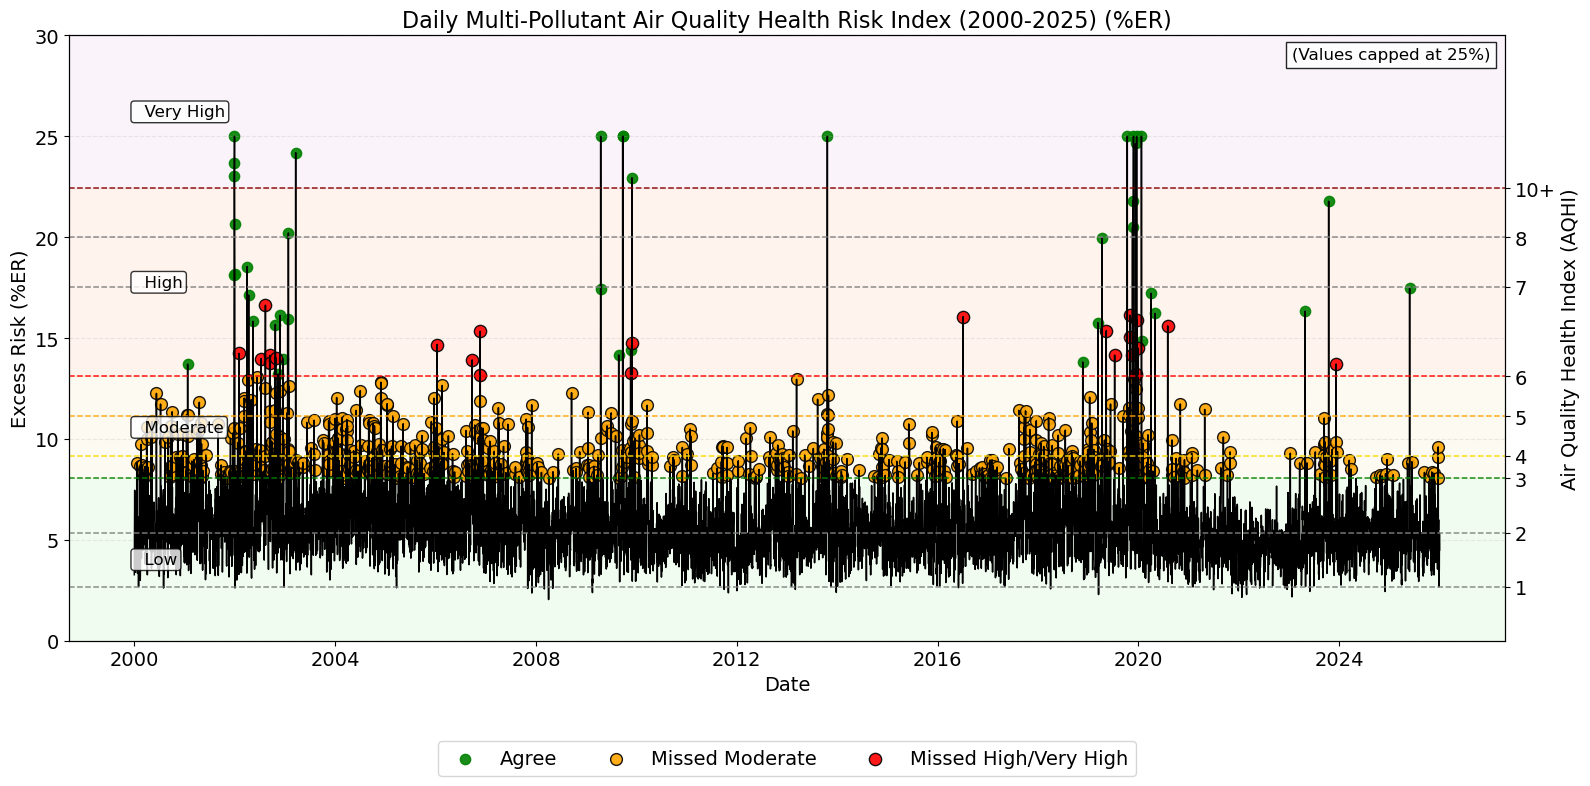

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# INPUT FILE
# ============================================================

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"

FIGURES_DIR.mkdir(exist_ok=True)

data_file = DATA_DIR / "Sydney_daily_3hr_max.csv"

fig_file = FIGURES_DIR / "Total_%ER_TimeSeries_PMmax_NO2_O3_Beta_CAP25_AXIS30_LEGEND_BOTTOM_UPDATED.png"

# ============================================================
# BREAKPOINTS / AQHI TABLE
# ============================================================
BOUNDARIES = [0.00, 2.68, 5.36, 8.05, 9.17, 11.13, 13.11, 17.55, 19.99, 22.43]

BANDS = [
    (0.00, 8.05,   "Low"),
    (8.05, 13.11,  "Moderate"),
    (13.11, 22.43, "High"),
    (22.43, None,  "Very High"),
]

BAND_COLORS = {
    "Low": "lightgreen",
    "Moderate": "khaki",
    "High": "lightsalmon",
    "Very High": "plum",
}

ANCHOR_LINE_COLORS = {
    8.05:  "green",
    9.17:  "gold",
    11.13: "orange",
    13.11: "red",
    22.43: "maroon",
}

sec_ticks  = [2.68, 5.36, 8.05, 9.17, 11.13, 13.11, 17.55, 19.99, 22.43]
sec_labels = ["1", "2", "3", "4", "5", "6", "7", "8", "10+"]

# ============================================================
# SETTINGS
# ============================================================
DATA_CAP = 25
Y_MAX_DISPLAY = 30
MODERATE_THRESHOLD = 8.05

DOT_SIZE_AGREE = 55
DOT_SIZE_MISSED_MODERATE = 72
DOT_SIZE_MISSED_HIGH = 78
DOT_ALPHA = 0.90

DAYFIRST = True

# Standardised Risk Coefficients (β per 1 µg/m³)
BETA = {
    "PM2.5": 0.000649,
    "PM10":  0.000409,
    "NO2":   0.000718,
    "O3":    0.000429,
}

REQUIRED_POLLUTANTS = ["PM2.5", "PM10", "NO2", "O3"]

# ============================================================
# HELPERS
# ============================================================
def er_percent_from_beta(conc: pd.Series, beta: float) -> pd.Series:
    c = pd.to_numeric(conc, errors="coerce")
    return (np.exp(beta * c) - 1.0) * 100.0

def classify_aqhi_band(er):
    if pd.isna(er):
        return np.nan
    if er <= 8.05:
        return "Low"
    elif er <= 13.11:
        return "Moderate"
    elif er <= 22.43:
        return "High"
    else:
        return "Very High"

# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(data_file)
if "Date" not in df.columns:
    raise ValueError("The input file must contain a 'Date' column.")

df["Date_raw"] = df["Date"]
d1 = pd.to_datetime(df["Date_raw"], errors="coerce", dayfirst=False)
d2 = pd.to_datetime(df.loc[d1.isna(), "Date_raw"], errors="coerce", dayfirst=DAYFIRST)
df["Date"] = d1
df.loc[d1.isna(), "Date"] = d2

for p in REQUIRED_POLLUTANTS:
    df[p] = pd.to_numeric(df[p], errors="coerce")
    df[f"{p}_%ER"] = er_percent_from_beta(df[p], BETA[p])

# ============================================================
# AQHI COMPUTATION
# ============================================================
df["PMmax_%ER"] = df[["PM2.5_%ER", "PM10_%ER"]].max(axis=1)
df["PMmax_source"] = np.where(df["PM2.5_%ER"] >= df["PM10_%ER"], "PM2.5", "PM10")

df["LP_PM2.5"] = BETA["PM2.5"] * df["PM2.5"]
df["LP_PM10"]  = BETA["PM10"]  * df["PM10"]
df["LP_NO2"]   = BETA["NO2"]   * df["NO2"]
df["LP_O3"]    = BETA["O3"]    * df["O3"]
df["LP_PMmax"] = np.maximum(df["LP_PM2.5"], df["LP_PM10"])

df["LP_total"] = df["LP_PMmax"] + df["LP_NO2"] + df["LP_O3"]
df["Total_%ER"] = (np.exp(df["LP_total"]) - 1.0) * 100.0
df["AQHI_Band"] = df["Total_%ER"].apply(classify_aqhi_band)

# ============================================================
# INTEGRITY REPORT
# ============================================================
n_total = len(df)
n_bad_date = df["Date"].isna().sum()
n_bad_total_er = df["Total_%ER"].isna().sum()
n_bad_poll_er = df[["PM2.5_%ER", "PM10_%ER", "NO2_%ER", "O3_%ER", "PMmax_%ER"]].isna().sum().sum()

print("========== DATA INTEGRITY CHECK ==========")
print(f"Total rows in file: {n_total}")
print(f"Rows with unparsed Date (NaT) AFTER robust parsing: {n_bad_date}")
print(f"Rows with non-numeric Total_%ER (NaN after computation): {n_bad_total_er}")
print(f"Total missing values across pollutant %ER cols: {int(n_bad_poll_er)}")
print("=========================================")

df_plot = df.dropna(subset=["Date", "Total_%ER", "PM2.5_%ER", "PM10_%ER", "NO2_%ER", "O3_%ER", "PMmax_%ER"]).copy()
df_plot = df_plot.sort_values("Date")

print("\nTop 10 highest Total_%ER days (verify spikes are present):")
print(df_plot.nlargest(10, "Total_%ER")[["Date", "Total_%ER", "PMmax_source", "AQHI_Band"]].to_string(index=False))

# ============================================================
# CAPPING SUMMARY
# ============================================================
mask_capped = df_plot["Total_%ER"] > DATA_CAP
df_plot["Total_%ER_plot"] = df_plot["Total_%ER"].clip(upper=DATA_CAP)
true_max = df_plot["Total_%ER"].max()
n_capped = int(mask_capped.sum())

print("\n========== CAPPING SUMMARY ==========")
print(f"True max Total_%ER in plotted data: {true_max:.2f}")
print(f"Days capped (Total_%ER > {DATA_CAP}): {n_capped}")
print("=====================================")

# ============================================================
# AGREEMENT / MISSED ANALYSIS
# ============================================================
df_plot["SinglePollutant_MaxER"] = df_plot[["PMmax_%ER", "NO2_%ER", "O3_%ER"]].max(axis=1)
aqhi_modplus = df_plot["Total_%ER"] >= MODERATE_THRESHOLD
single_flags_modplus = df_plot["SinglePollutant_MaxER"] >= MODERATE_THRESHOLD
agree_mask = aqhi_modplus & single_flags_modplus
missed_mask = aqhi_modplus & (~single_flags_modplus)

missed_moderate_mask = missed_mask & (df_plot["AQHI_Band"] == "Moderate")
missed_high_mask = missed_mask & (df_plot["AQHI_Band"] == "High")
missed_very_high_mask = missed_mask & (df_plot["AQHI_Band"] == "Very High")
missed_highplus_mask = missed_mask & (df_plot["AQHI_Band"].isin(["High", "Very High"]))

agree_y = df_plot.loc[agree_mask, "Total_%ER_plot"]
missed_moderate_y = df_plot.loc[missed_moderate_mask, "Total_%ER_plot"]
missed_highplus_y = df_plot.loc[missed_highplus_mask, "Total_%ER_plot"]

print("\n========== AGREEMENT / MISSED COUNTS (MODERATE+) ==========")
print(f"AQHI Moderate+ days (Total_%ER >= {MODERATE_THRESHOLD}): {int(aqhi_modplus.sum())}")
print(f"Agree (AQHI Moderate+ & single-pollutant flags): {int(agree_mask.sum())}")
print(f"Missed (AQHI Moderate+ but single-pollutant does NOT flag): {int(missed_mask.sum())}")
print("===========================================================")

print("\n========== MISSED DAYS BY AQHI CATEGORY ==========")
print(f"Missed Moderate days   : {int(missed_moderate_mask.sum())}")
print(f"Missed High days       : {int(missed_high_mask.sum())}")
print(f"Missed Very High days  : {int(missed_very_high_mask.sum())}")
print(f"Missed High+Very High  : {int(missed_highplus_mask.sum())}")
print("==================================================")

if int(missed_mask.sum()) > 0:
    n_missed_total = int(missed_mask.sum())
    print("\n========== MISSED CATEGORY PERCENTAGES ==========")
    print(f"Moderate missed   : {missed_moderate_mask.sum() / n_missed_total * 100:.2f}%")
    print(f"High missed       : {missed_high_mask.sum() / n_missed_total * 100:.2f}%")
    print(f"Very High missed  : {missed_very_high_mask.sum() / n_missed_total * 100:.2f}%")
    print("=================================================")

aqhi_counts = df_plot["AQHI_Band"].value_counts().reindex(["Low", "Moderate", "High", "Very High"], fill_value=0)
aqhi_percent = (aqhi_counts / len(df_plot) * 100).round(2)
print("\n========== OVERALL AQHI DISTRIBUTION ==========")
for band in ["Low", "Moderate", "High", "Very High"]:
    print(f"{band:10s}: {int(aqhi_counts[band])} days ({aqhi_percent[band]:.2f}%)")
print("===============================================")

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(16, 9))

# Main line
ax.plot(df_plot["Date"], df_plot["Total_%ER_plot"], linewidth=1.1, color="black")

# Update font sizes to 14
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Excess Risk (%ER)", fontsize=14)
ax.set_title("Daily Multi-Pollutant Air Quality Health Risk Index (2000-2025) (%ER)", fontsize=16)
ax.set_ylim(0, Y_MAX_DISPLAY)
ax.tick_params(axis='both', labelsize=14)

# Bands
xmin = df_plot["Date"].min()
for ymin, ymax_band, label in BANDS:
    y_vis_max = min(ymax_band if ymax_band else Y_MAX_DISPLAY, Y_MAX_DISPLAY)
    ax.axhspan(ymin, y_vis_max, alpha=0.12, color=BAND_COLORS[label])
    ax.text(xmin, (ymin + y_vis_max) / 2, f"  {label}", va="center", ha="left", fontsize=12,
            bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.2", alpha=0.8))

# Breakpoints
for y in BOUNDARIES[1:]:
    if y <= Y_MAX_DISPLAY:
        ax.axhline(y=y, linestyle="--", linewidth=1.1, color=ANCHOR_LINE_COLORS.get(y, "gray"), alpha=0.9)

# Scatter
ax.scatter(df_plot.loc[agree_mask, "Date"], agree_y, s=DOT_SIZE_AGREE, color="green", alpha=DOT_ALPHA, label="Agree")
ax.scatter(df_plot.loc[missed_moderate_mask, "Date"], missed_moderate_y, s=DOT_SIZE_MISSED_MODERATE, color="orange", 
           alpha=DOT_ALPHA, edgecolors="black", label="Missed Moderate")
ax.scatter(df_plot.loc[missed_highplus_mask, "Date"], missed_highplus_y, s=DOT_SIZE_MISSED_HIGH, color="red", 
           alpha=DOT_ALPHA, edgecolors="black", label="Missed High/Very High")

# Secondary Y
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_ylabel("Air Quality Health Index (AQHI)", fontsize=14)
ax2.set_yticks(sec_ticks)
ax2.set_yticklabels(sec_labels, fontsize=14)

ax.grid(axis="y", linestyle="--", alpha=0.25)

# Legend
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, fontsize=14)

# Capping text
ax.text(0.99, 0.98, f"(Values capped at {DATA_CAP}%)", transform=ax.transAxes, ha="right", va="top", fontsize=12,
        bbox=dict(facecolor="white", alpha=0.85))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(fig_file, dpi=300, bbox_inches="tight")
plt.show()

========== DATA INTEGRITY CHECK ==========
Total rows in file: 9497
Rows with unparsed Date (NaT): 0
Rows with missing Total_%ER: 0

========== OVERALL AQHI DISTRIBUTION (ALL DAYS) ==========
        AQHI category  Days  % of all days
      Low Health Risk  8691          91.51
 Moderate Health Risk   742           7.81
     High Health Risk    50           0.53
Very High Health Risk    14           0.15


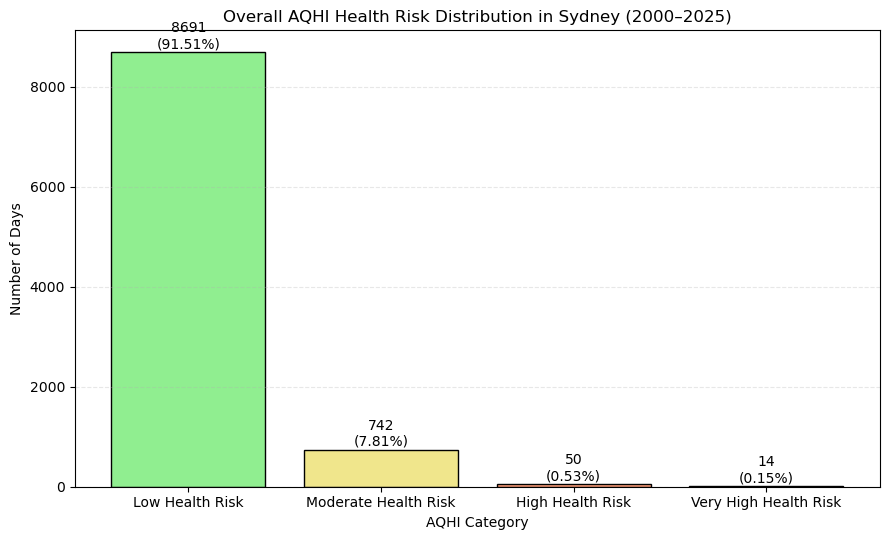

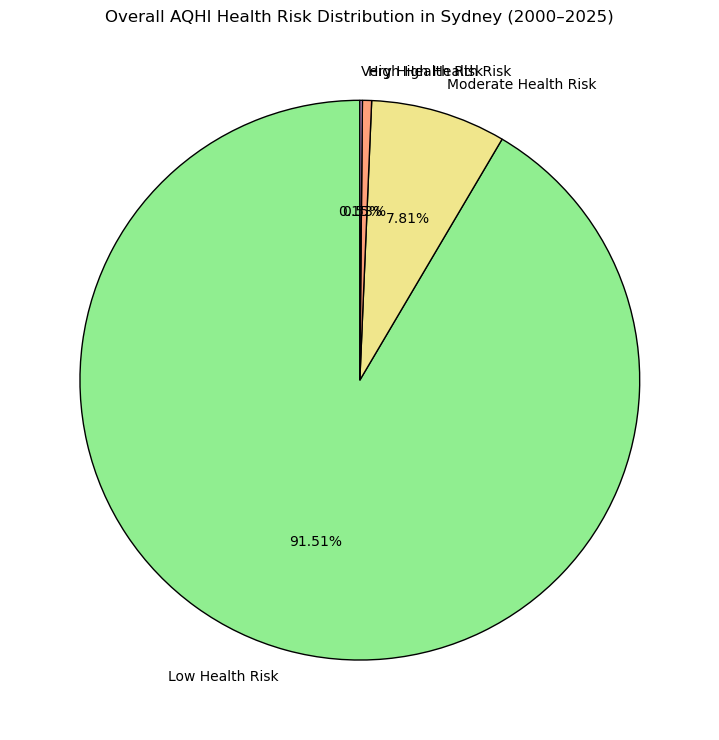


========== MODERATE TO VERY HIGH SUBSET ==========
Total Moderate-to-Very-High rows retained: 806
Rows with unparsed Date (NaT): 0
Rows with missing Total_%ER: 0

AQHI band counts (Moderate to Very High only):
AQHI_Band
Moderate     742
High          50
Very High     14

Top 10 highest Total_%ER days:
      Date  Total_%ER AQHI_Band Dominant_driver PMmax_source
2001-12-30  53.951526 Very High           PMmax        PM2.5
2019-10-12  42.455787 Very High           PMmax        PM2.5
2009-09-23  40.260034 Very High           PMmax        PM2.5
2020-01-23  35.260289 Very High           PMmax         PM10
2009-09-26  32.847318 Very High           PMmax         PM10
2019-11-26  32.240044 Very High           PMmax         PM10
2019-12-19  28.545546 Very High           PMmax        PM2.5
2013-10-21  25.553603 Very High           PMmax        PM2.5
2009-04-16  25.133778 Very High           PMmax         PM10
2019-12-11  24.647978 Very High           PMmax         PM10

========== DRIVER SUMMAR

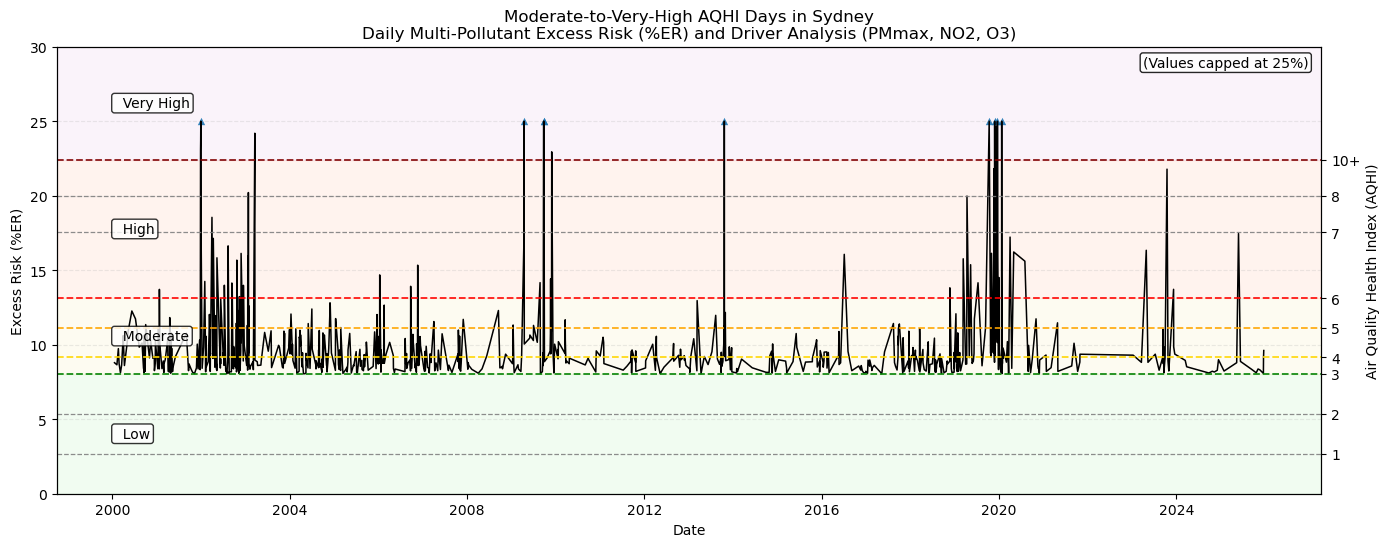

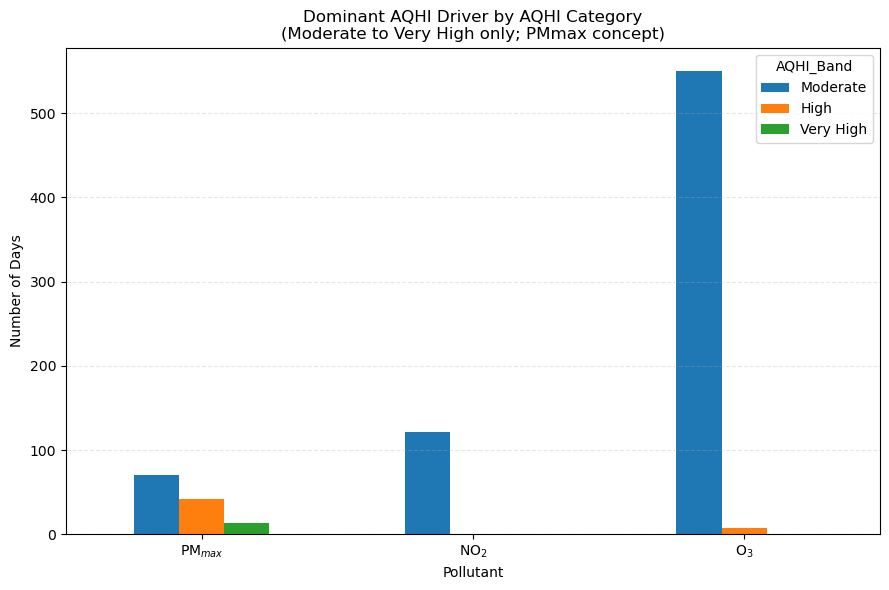

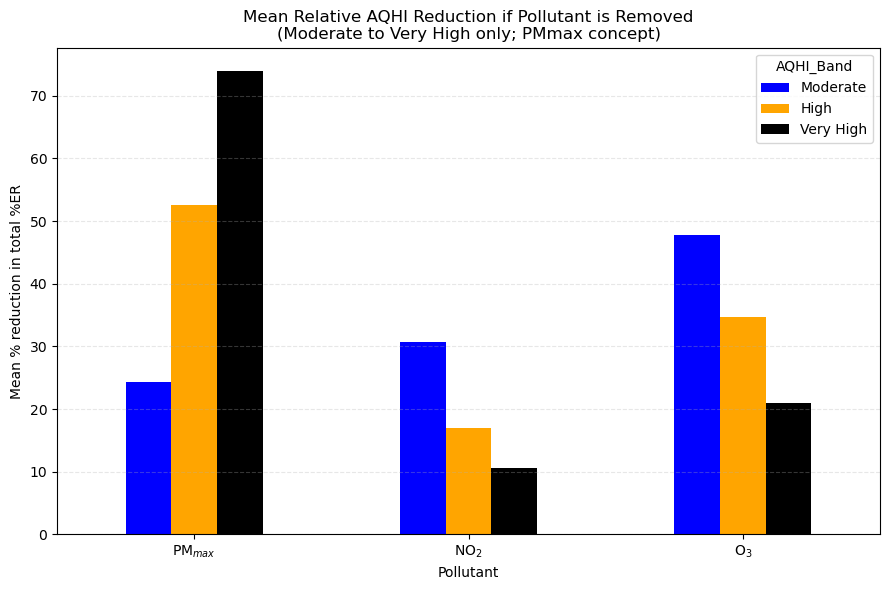

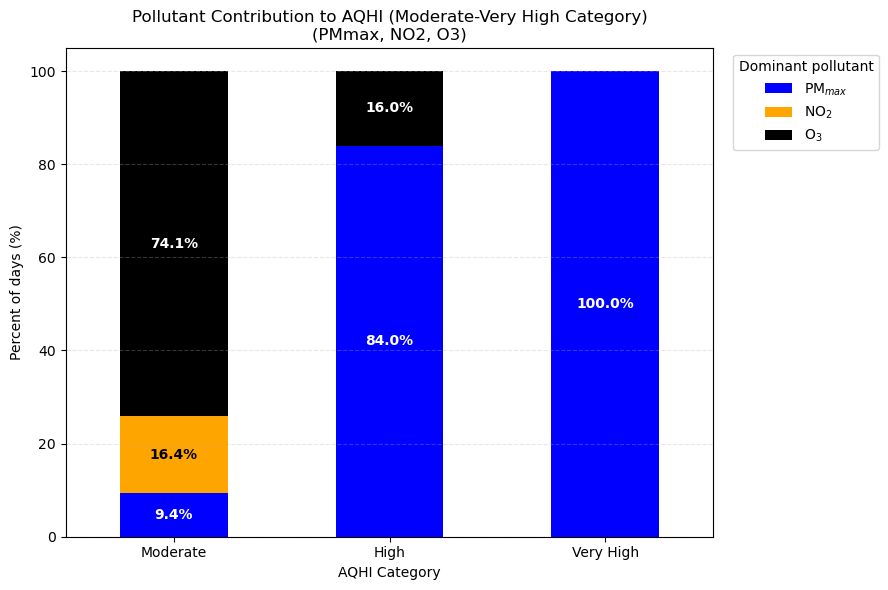

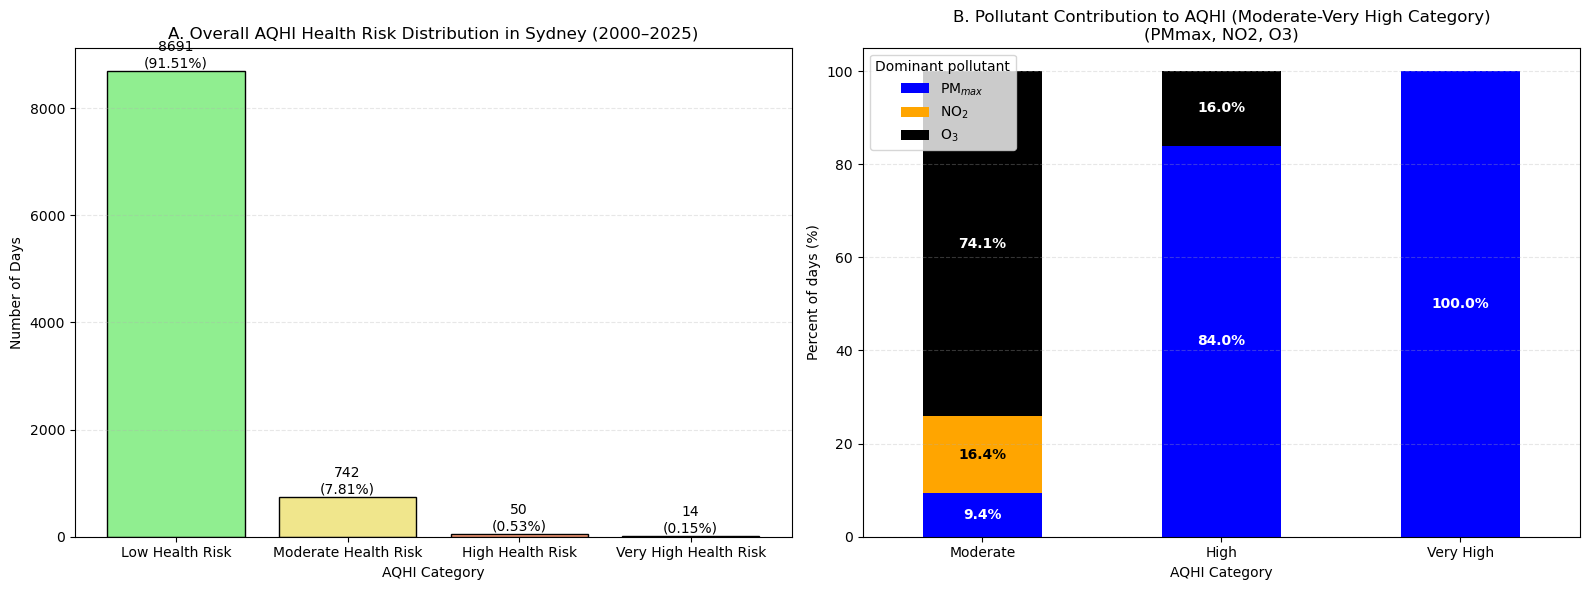


========== FINAL BIG-PICTURE AQHI SUMMARY ==========
Low Health Risk:       8691 days (91.51%)
Moderate Health Risk:  742 days (7.81%)
High Health Risk:      50 days (0.53%)
Very High Health Risk: 14 days (0.15%)

Files saved:
..\outputs\AQHI_Overall_Distribution_PMmax_beta.csv
..\outputs\AQHI_ModerateToVeryHigh_Daily_Output_PMmax_beta.csv
..\outputs\AQHI_ModerateToVeryHigh_Summary_PMmax_beta.csv
..\outputs\AQHI_PMmax_Source_Summary_PMmax_beta.csv
..\figures\AQHI_Overall_Distribution_Bar_PMmax_beta.png
..\figures\AQHI_Overall_Distribution_Pie_PMmax_beta.png
..\figures\AQHI_ModerateToVeryHigh_TimeSeries_DriverAnalysis_PMmax_beta.png
..\figures\AQHI_ModerateToVeryHigh_DominantDriver_ByCategory_PMmax_beta.png
..\figures\AQHI_ModerateToVeryHigh_MeanReduction_ByCategory_PMmax_beta.png
..\figures\AQHI_ModerateToVeryHigh_DominantShare_ByCategory_PMmax_beta.png
..\figures\AQHI_Combined_Overall_and_PollutantContribution_PMmax_beta.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# INPUT FILE
# ============================================================

PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

FIGURES_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

data_file = DATA_DIR / "Sydney_daily_3hr_max.csv"

# ============================================================
# OUTPUT FILES
# ============================================================

fig_overall_bar_file   = FIGURES_DIR / "AQHI_Overall_Distribution_Bar_PMmax_beta.png"
fig_overall_pie_file   = FIGURES_DIR / "AQHI_Overall_Distribution_Pie_PMmax_beta.png"
fig_main_file          = FIGURES_DIR / "AQHI_ModerateToVeryHigh_TimeSeries_DriverAnalysis_PMmax_beta.png"
fig_driver_bar_file    = FIGURES_DIR / "AQHI_ModerateToVeryHigh_DominantDriver_ByCategory_PMmax_beta.png"
fig_contrib_bar_file   = FIGURES_DIR / "AQHI_ModerateToVeryHigh_MeanReduction_ByCategory_PMmax_beta.png"
fig_share_file         = FIGURES_DIR / "AQHI_ModerateToVeryHigh_DominantShare_ByCategory_PMmax_beta.png"
fig_combined_file      = FIGURES_DIR / "AQHI_Combined_Overall_and_PollutantContribution_PMmax_beta.png"

csv_overall_file       = OUTPUTS_DIR / "AQHI_Overall_Distribution_PMmax_beta.csv"
csv_daily_file         = OUTPUTS_DIR / "AQHI_ModerateToVeryHigh_Daily_Output_PMmax_beta.csv"
csv_summary_file       = OUTPUTS_DIR / "AQHI_ModerateToVeryHigh_Summary_PMmax_beta.csv"
csv_pmmax_source_file  = OUTPUTS_DIR / "AQHI_PMmax_Source_Summary_PMmax_beta.csv"

# ============================================================
# AQHI BREAKPOINTS / BANDS
# ============================================================
BOUNDARIES = [0.00, 2.68, 5.36, 8.05, 9.17, 11.13, 13.11, 17.55, 19.99, 22.43]

BANDS = [
    (0.00, 8.05,   "Low"),
    (8.05, 13.11,  "Moderate"),
    (13.11, 22.43, "High"),
    (22.43, None,  "Very High"),
]

BAND_COLORS = {
    "Low": "lightgreen",
    "Moderate": "khaki",
    "High": "lightsalmon",
    "Very High": "plum",
}

ANCHOR_LINE_COLORS = {
    8.05:  "green",
    9.17:  "gold",
    11.13: "orange",
    13.11: "red",
    22.43: "maroon",
}

sec_ticks  = [2.68, 5.36, 8.05, 9.17, 11.13, 13.11, 17.55, 19.99, 22.43]
sec_labels = ["1", "2", "3", "4", "5", "6", "7", "8", "10+"]

# ============================================================
# SETTINGS
# ============================================================
DATA_CAP = 25
Y_MAX_DISPLAY = 30
MODERATE_THRESHOLD = 8.05
DAYFIRST = True

# ============================================================
# STANDARDISED RISK COEFFICIENTS (β per 1 µg/m³)
# Derived from Orellano et al. (2020):
# β = ln(RR per 10 µg/m³) / 10
# ============================================================
BETA = {
    "PM2.5": 0.000649,
    "PM10":  0.000409,
    "NO2":   0.000718,
    "O3":    0.000429,
}

# ============================================================
# REQUIRED POLLUTANTS
# ============================================================
REQUIRED_POLLUTANTS = ["PM2.5", "PM10", "NO2", "O3"]

# ============================================================
# CUSTOM COLORS FOR POLLUTANT CONTRIBUTION PLOTS
# ============================================================
POLLUTANT_COLORS = {
    "PMmax": "blue",
    "NO2": "orange",
    "O3": "black"
}

# Display labels with subscripts
POLLUTANT_LABELS = {
    "PMmax": r"PM$_{max}$",
    "NO2": r"NO$_2$",
    "O3": r"O$_3$"
}

# ============================================================
# HELPERS
# ============================================================
def er_percent_from_beta(conc: pd.Series, beta: float) -> pd.Series:
    c = pd.to_numeric(conc, errors="coerce")
    return (np.exp(beta * c) - 1.0) * 100.0


def classify_aqhi_band(er: float):
    if pd.isna(er):
        return np.nan
    if er <= 8.05:
        return "Low"
    elif er <= 13.11:
        return "Moderate"
    elif er <= 22.43:
        return "High"
    else:
        return "Very High"


def aqhi_value_from_er(er: float):
    if pd.isna(er):
        return np.nan
    if er <= 2.68:
        return "1"
    elif er <= 5.36:
        return "2"
    elif er <= 8.05:
        return "3"
    elif er <= 9.17:
        return "4"
    elif er <= 11.13:
        return "5"
    elif er <= 13.11:
        return "6"
    elif er <= 17.55:
        return "7"
    elif er <= 19.99:
        return "8"
    elif er <= 22.43:
        return "9-10"
    else:
        return "10+"


def safe_pct(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    return np.where(denominator > 0, (numerator / denominator) * 100.0, np.nan)


def add_stacked_labels(ax, pivot_df, min_height=4.0, text_color_default="white"):
    """
    Add centered percentage labels inside stacked bar segments.
    Only labels segments >= min_height (%).
    """
    x_positions = np.arange(len(pivot_df.index))
    cumulative_bottom = np.zeros(len(pivot_df.index))

    for col in pivot_df.columns:
        heights = pivot_df[col].values
        for i, h in enumerate(heights):
            if h >= min_height:
                y = cumulative_bottom[i] + h / 2.0
                # black text on orange for readability, white elsewhere
                if col == "NO2":
                    txt_color = "black"
                else:
                    txt_color = text_color_default
                ax.text(
                    x_positions[i],
                    y,
                    f"{h:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color=txt_color,
                    fontweight="bold"
                )
        cumulative_bottom += heights


# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(data_file)

if "Date" not in df.columns:
    raise ValueError("The input file must contain a 'Date' column.")

df["Date_raw"] = df["Date"]

d1 = pd.to_datetime(df["Date_raw"], errors="coerce", dayfirst=False)
d2 = pd.to_datetime(df.loc[d1.isna(), "Date_raw"], errors="coerce", dayfirst=DAYFIRST)

df["Date"] = d1
df.loc[d1.isna(), "Date"] = d2

for p in REQUIRED_POLLUTANTS:
    if p not in df.columns:
        raise ValueError(f"Missing required pollutant column: {p}. Available columns: {list(df.columns)}")
    df[p] = pd.to_numeric(df[p], errors="coerce")

# ============================================================
# COMPUTE INDIVIDUAL POLLUTANT %ER USING β
# ============================================================
for p in REQUIRED_POLLUTANTS:
    df[f"{p}_%ER"] = er_percent_from_beta(df[p], BETA[p])

# ============================================================
# PMmax RULE
# ============================================================
df["PMmax_%ER"] = df[["PM2.5_%ER", "PM10_%ER"]].max(axis=1)
df["PMmax_source"] = np.where(df["PM2.5_%ER"] >= df["PM10_%ER"], "PM2.5", "PM10")

df["LP_PM2.5"] = BETA["PM2.5"] * df["PM2.5"]
df["LP_PM10"]  = BETA["PM10"]  * df["PM10"]
df["LP_NO2"]   = BETA["NO2"]   * df["NO2"]
df["LP_O3"]    = BETA["O3"]    * df["O3"]

df["LP_PMmax"] = np.maximum(df["LP_PM2.5"], df["LP_PM10"])
df["LP_total"] = df["LP_PMmax"] + df["LP_NO2"] + df["LP_O3"]
df["Total_%ER"] = (np.exp(df["LP_total"]) - 1.0) * 100.0

# ============================================================
# AQHI CLASSIFICATION (ALL DAYS)
# ============================================================
df["AQHI_Band"] = df["Total_%ER"].apply(classify_aqhi_band)
df["AQHI_Value"] = df["Total_%ER"].apply(aqhi_value_from_er)

# ============================================================
# DATA INTEGRITY
# ============================================================
print("========== DATA INTEGRITY CHECK ==========")
print(f"Total rows in file: {len(df)}")
print(f"Rows with unparsed Date (NaT): {df['Date'].isna().sum()}")
print(f"Rows with missing Total_%ER: {df['Total_%ER'].isna().sum()}")
print("=========================================")

# ============================================================
# OVERALL AQHI DISTRIBUTION (ALL DAYS)
# ============================================================
total_days = len(df)

aqhi_counts = df["AQHI_Band"].value_counts().reindex(
    ["Low", "Moderate", "High", "Very High"],
    fill_value=0
)

aqhi_percent = (aqhi_counts / total_days) * 100

aqhi_summary = pd.DataFrame({
    "AQHI category": [
        "Low Health Risk",
        "Moderate Health Risk",
        "High Health Risk",
        "Very High Health Risk"
    ],
    "Days": aqhi_counts.values,
    "% of all days": aqhi_percent.round(2).values
})

print("\n========== OVERALL AQHI DISTRIBUTION (ALL DAYS) ==========")
print(aqhi_summary.to_string(index=False))
print("==========================================================")

aqhi_summary.to_csv(csv_overall_file, index=False)

# ============================================================
# PLOT 1: OVERALL AQHI DISTRIBUTION BAR CHART
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5.5))

bar_colors = ["lightgreen", "khaki", "lightsalmon", "plum"]
bars = ax.bar(
    aqhi_summary["AQHI category"],
    aqhi_summary["Days"],
    color=bar_colors,
    edgecolor="black"
)

ax.set_title("Overall AQHI Health Risk Distribution in Sydney (2000–2025)")
ax.set_xlabel("AQHI Category")
ax.set_ylabel("Number of Days")
ax.grid(axis="y", linestyle="--", alpha=0.3)

for bar, days, pct in zip(bars, aqhi_summary["Days"], aqhi_summary["% of all days"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(15, total_days * 0.001),
        f"{days}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(fig_overall_bar_file, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 2: OVERALL AQHI DISTRIBUTION PIE CHART
# ============================================================
fig, ax = plt.subplots(figsize=(7.5, 7.5))

ax.pie(
    aqhi_summary["Days"],
    labels=aqhi_summary["AQHI category"],
    autopct=lambda p: f"{p:.2f}%",
    startangle=90,
    colors=bar_colors,
    wedgeprops=dict(edgecolor="black")
)

ax.set_title("Overall AQHI Health Risk Distribution in Sydney (2000–2025)")
plt.tight_layout()
plt.savefig(fig_overall_pie_file, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# FILTER TO MODERATE TO VERY HIGH ONLY
# ============================================================
df_modplus = df[df["Total_%ER"] > MODERATE_THRESHOLD].copy()

print("\n========== MODERATE TO VERY HIGH SUBSET ==========")
print(f"Total Moderate-to-Very-High rows retained: {len(df_modplus)}")
print(f"Rows with unparsed Date (NaT): {df_modplus['Date'].isna().sum()}")
print(f"Rows with missing Total_%ER: {df_modplus['Total_%ER'].isna().sum()}")
print("==================================================")

print("\nAQHI band counts (Moderate to Very High only):")
print(df_modplus["AQHI_Band"].value_counts().reindex(["Moderate", "High", "Very High"], fill_value=0).to_string())

# ============================================================
# LEAVE-ONE-POLLUTANT-OUT ANALYSIS
# ============================================================
df_modplus["ER_without_PMmax"] = (np.exp(df_modplus["LP_NO2"] + df_modplus["LP_O3"]) - 1.0) * 100.0
df_modplus["ER_without_NO2"]   = (np.exp(df_modplus["LP_PMmax"] + df_modplus["LP_O3"]) - 1.0) * 100.0
df_modplus["ER_without_O3"]    = (np.exp(df_modplus["LP_PMmax"] + df_modplus["LP_NO2"]) - 1.0) * 100.0

df_modplus["Drop_PMmax"] = df_modplus["Total_%ER"] - df_modplus["ER_without_PMmax"]
df_modplus["Drop_NO2"]   = df_modplus["Total_%ER"] - df_modplus["ER_without_NO2"]
df_modplus["Drop_O3"]    = df_modplus["Total_%ER"] - df_modplus["ER_without_O3"]

df_modplus["PctDrop_PMmax"] = safe_pct(df_modplus["Drop_PMmax"], df_modplus["Total_%ER"])
df_modplus["PctDrop_NO2"]   = safe_pct(df_modplus["Drop_NO2"], df_modplus["Total_%ER"])
df_modplus["PctDrop_O3"]    = safe_pct(df_modplus["Drop_O3"], df_modplus["Total_%ER"])

drop_cols = ["Drop_PMmax", "Drop_NO2", "Drop_O3"]
driver_map = {
    "Drop_PMmax": "PMmax",
    "Drop_NO2": "NO2",
    "Drop_O3": "O3"
}
df_modplus["Dominant_driver"] = df_modplus[drop_cols].idxmax(axis=1).map(driver_map)

# ============================================================
# SORT / CLEAN
# ============================================================
df_plot = df_modplus.dropna(subset=["Date", "Total_%ER"]).copy().sort_values("Date")

print("\nTop 10 highest Total_%ER days:")
print(df_plot.nlargest(10, "Total_%ER")[[
    "Date", "Total_%ER", "AQHI_Band", "Dominant_driver", "PMmax_source"
]].to_string(index=False))

# ============================================================
# SUMMARY TABLE BY AQHI CATEGORY
# ============================================================
summary_rows = []

for band in ["Moderate", "High", "Very High"]:
    sub = df_plot[df_plot["AQHI_Band"] == band].copy()
    if len(sub) == 0:
        continue

    total_band_days = len(sub)
    mean_total_er = sub["Total_%ER"].mean()
    median_total_er = sub["Total_%ER"].median()
    dominant_counts = sub["Dominant_driver"].value_counts(dropna=False)

    for pollutant in ["PMmax", "NO2", "O3"]:
        dominant_n = int(dominant_counts.get(pollutant, 0))
        dominant_pct = (dominant_n / total_band_days) * 100.0
        mean_contribution = sub[f"PctDrop_{pollutant}"].mean()

        summary_rows.append({
            "AQHI_Band": band,
            "Pollutant": pollutant,
            "Days_in_band": total_band_days,
            "Mean_Total_%ER": round(mean_total_er, 3),
            "Median_Total_%ER": round(median_total_er, 3),
            "Dominant_days_n": dominant_n,
            "Dominant_days_%": round(dominant_pct, 2),
            "Mean_%Drop_if_removed": round(mean_contribution, 2) if pd.notna(mean_contribution) else np.nan
        })

summary_df = pd.DataFrame(summary_rows)

band_summary = (
    df_plot.groupby("AQHI_Band")
    .size()
    .reindex(["Moderate", "High", "Very High"], fill_value=0)
    .reset_index(name="Days")
)

pmmax_source_summary = (
    df_plot.groupby(["AQHI_Band", "PMmax_source"])
    .size()
    .reset_index(name="Days")
)

print("\n========== DRIVER SUMMARY (Moderate to Very High only; PMmax concept) ==========")
print(summary_df.to_string(index=False))

print("\n========== AQHI BAND SUMMARY ==========")
print(band_summary.to_string(index=False))

print("\n========== PMmax SOURCE SUMMARY ==========")
print(pmmax_source_summary.to_string(index=False))

# ============================================================
# SAVE OUTPUT TABLES
# ============================================================
aqhi_summary.to_csv(csv_overall_file, index=False)
summary_df.to_csv(csv_summary_file, index=False)
pmmax_source_summary.to_csv(csv_pmmax_source_file, index=False)

daily_cols = [
    "Date",
    "PM2.5", "PM10", "NO2", "O3",
    "PM2.5_%ER", "PM10_%ER", "NO2_%ER", "O3_%ER", "PMmax_%ER",
    "PMmax_source",
    "LP_PM2.5", "LP_PM10", "LP_PMmax", "LP_NO2", "LP_O3", "LP_total",
    "Total_%ER", "AQHI_Band", "AQHI_Value",
    "ER_without_PMmax", "ER_without_NO2", "ER_without_O3",
    "Drop_PMmax", "Drop_NO2", "Drop_O3",
    "PctDrop_PMmax", "PctDrop_NO2", "PctDrop_O3",
    "Dominant_driver"
]
df_plot[daily_cols].to_csv(csv_daily_file, index=False)

# ============================================================
# PLOT 3: TIME SERIES FOR MODERATE TO VERY HIGH DAYS
# ============================================================
df_plot["Total_%ER_plot"] = df_plot["Total_%ER"].clip(upper=DATA_CAP)
mask_capped = df_plot["Total_%ER"] > DATA_CAP
n_capped = int(mask_capped.sum())

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_plot["Date"], df_plot["Total_%ER_plot"], linewidth=1.1, color="black")

ax.set_xlabel("Date")
ax.set_ylabel("Excess Risk (%ER)")
ax.set_title(
    "Moderate-to-Very-High AQHI Days in Sydney\n"
    "Daily Multi-Pollutant Excess Risk (%ER) and Driver Analysis (PMmax, NO2, O3)"
)

ax.set_ylim(0, Y_MAX_DISPLAY)

xmin = df_plot["Date"].min()
for ymin, ymax_band, label in BANDS:
    if ymax_band is None:
        ymax_band = Y_MAX_DISPLAY
    ymin_vis = max(ymin, 0)
    ymax_vis = min(ymax_band, Y_MAX_DISPLAY)
    if ymin_vis >= Y_MAX_DISPLAY:
        continue

    ax.axhspan(ymin_vis, ymax_vis, alpha=0.12, color=BAND_COLORS[label])

    y_text = (ymin_vis + ymax_vis) / 2
    ax.text(
        xmin, y_text,
        f"  {label}",
        va="center", ha="left", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.2", alpha=0.8)
    )

for y in BOUNDARIES[1:]:
    if y > Y_MAX_DISPLAY:
        continue
    c = ANCHOR_LINE_COLORS.get(y, "gray")
    lw = 1.3 if y in ANCHOR_LINE_COLORS else 0.9
    ax.axhline(y=y, linestyle="--", linewidth=lw, color=c, alpha=0.9)

if n_capped > 0:
    ax.scatter(
        df_plot.loc[mask_capped, "Date"],
        [DATA_CAP] * n_capped,
        marker="^",
        s=28,
        linewidths=0,
        alpha=0.9
    )

ax.text(
    0.99, 0.98,
    f"(Values capped at {DATA_CAP}%)",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.2", alpha=0.85)
)

ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_ylabel("Air Quality Health Index (AQHI)")
ax2.set_yticks(sec_ticks)
ax2.set_yticklabels(sec_labels)

ax.grid(axis="y", linestyle="--", alpha=0.25)

fig.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.savefig(fig_main_file, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 4: DOMINANT DRIVER FREQUENCY BY AQHI CATEGORY
# ============================================================
dominant_counts = (
    df_plot.groupby(["AQHI_Band", "Dominant_driver"])
    .size()
    .reset_index(name="Days")
)

pollutant_order = ["PMmax", "NO2", "O3"]
band_order = ["Moderate", "High", "Very High"]

pivot_counts = dominant_counts.pivot(index="Dominant_driver", columns="AQHI_Band", values="Days")
pivot_counts = pivot_counts.reindex(pollutant_order).fillna(0)
pivot_counts = pivot_counts.reindex(columns=band_order)

fig, ax = plt.subplots(figsize=(9, 6))
pivot_counts.plot(kind="bar", ax=ax)
ax.set_title("Dominant AQHI Driver by AQHI Category\n(Moderate to Very High only; PMmax concept)")
ax.set_xlabel("Pollutant")
ax.set_ylabel("Number of Days")
ax.set_xticklabels([POLLUTANT_LABELS[p] for p in pivot_counts.index], rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(fig_driver_bar_file, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 5: MEAN % REDUCTION IF POLLUTANT IS REMOVED
# ============================================================
pivot_contrib = summary_df.pivot(index="Pollutant", columns="AQHI_Band", values="Mean_%Drop_if_removed")
pivot_contrib = pivot_contrib.reindex(pollutant_order).reindex(columns=band_order)

fig, ax = plt.subplots(figsize=(9, 6))
pivot_contrib.plot(kind="bar", ax=ax, color=[POLLUTANT_COLORS[p] for p in pivot_contrib.index])
ax.set_title("Mean Relative AQHI Reduction if Pollutant is Removed\n(Moderate to Very High only; PMmax concept)")
ax.set_xlabel("Pollutant")
ax.set_ylabel("Mean % reduction in total %ER")
ax.set_xticklabels([POLLUTANT_LABELS[p] for p in pivot_contrib.index], rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(fig_contrib_bar_file, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 6: SHARE OF DOMINANT DRIVER WITHIN EACH AQHI CATEGORY
# ============================================================
dominant_share = dominant_counts.copy()
band_totals = dominant_share.groupby("AQHI_Band")["Days"].transform("sum")
dominant_share["Percent"] = (dominant_share["Days"] / band_totals) * 100.0

pivot_share = dominant_share.pivot(index="AQHI_Band", columns="Dominant_driver", values="Percent")
pivot_share = pivot_share.reindex(index=band_order, columns=pollutant_order).fillna(0)

fig, ax = plt.subplots(figsize=(9, 6))
pivot_share.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[POLLUTANT_COLORS[p] for p in pivot_share.columns]
)
ax.set_title("Pollutant Contribution to AQHI (Moderate-Very High Category)\n(PMmax, NO2, O3)")
ax.set_xlabel("AQHI Category")
ax.set_ylabel("Percent of days (%)")
ax.tick_params(axis="x", rotation=0)
legend_labels = [POLLUTANT_LABELS[p] for p in pivot_share.columns]
ax.legend(legend_labels, title="Dominant pollutant", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Add labels inside stacked bars
add_stacked_labels(ax, pivot_share, min_height=4.0)

plt.tight_layout()
plt.savefig(fig_share_file, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT 7: COMBINED 1x2 FIGURE (A left, B right)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------
# A. Overall AQHI distribution
# -------------------------
ax1 = axes[0]
bars = ax1.bar(
    aqhi_summary["AQHI category"],
    aqhi_summary["Days"],
    color=bar_colors,
    edgecolor="black"
)
ax1.set_title("A. Overall AQHI Health Risk Distribution in Sydney (2000–2025)")
ax1.set_xlabel("AQHI Category")
ax1.set_ylabel("Number of Days")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

for bar, days, pct in zip(bars, aqhi_summary["Days"], aqhi_summary["% of all days"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(15, total_days * 0.001),
        f"{days}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax1.tick_params(axis="x", rotation=0)

# -------------------------
# B. Pollutant contribution
# -------------------------
ax2 = axes[1]
pivot_share.plot(
    kind="bar",
    stacked=True,
    ax=ax2,
    color=[POLLUTANT_COLORS[p] for p in pivot_share.columns]
)
ax2.set_title("B. Pollutant Contribution to AQHI (Moderate-Very High Category)\n(PMmax, NO2, O3)")
ax2.set_xlabel("AQHI Category")
ax2.set_ylabel("Percent of days (%)")
ax2.tick_params(axis="x", rotation=0)
legend_labels = [POLLUTANT_LABELS[p] for p in pivot_share.columns]
ax2.legend(legend_labels, title="Dominant pollutant", loc="upper left")
ax2.grid(axis="y", linestyle="--", alpha=0.3)

# Add labels inside stacked bars in subplot B
add_stacked_labels(ax2, pivot_share, min_height=4.0)

plt.tight_layout()
plt.savefig(fig_combined_file, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# FINAL SUMMARY PRINT
# ============================================================
low_days = int(aqhi_counts["Low"])
moderate_days = int(aqhi_counts["Moderate"])
high_days = int(aqhi_counts["High"])
very_high_days = int(aqhi_counts["Very High"])

low_pct = aqhi_percent["Low"]
moderate_pct = aqhi_percent["Moderate"]
high_pct = aqhi_percent["High"]
very_high_pct = aqhi_percent["Very High"]

print("\n========== FINAL BIG-PICTURE AQHI SUMMARY ==========")
print(f"Low Health Risk:       {low_days} days ({low_pct:.2f}%)")
print(f"Moderate Health Risk:  {moderate_days} days ({moderate_pct:.2f}%)")
print(f"High Health Risk:      {high_days} days ({high_pct:.2f}%)")
print(f"Very High Health Risk: {very_high_days} days ({very_high_pct:.2f}%)")
print("====================================================")

print("\nFiles saved:")
print(csv_overall_file)
print(csv_daily_file)
print(csv_summary_file)
print(csv_pmmax_source_file)
print(fig_overall_bar_file)
print(fig_overall_pie_file)
print(fig_main_file)
print(fig_driver_bar_file)
print(fig_contrib_bar_file)
print(fig_share_file)
print(fig_combined_file)

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from calendar import isleap
from scipy.stats import linregress
from pathlib import Path

# -------------------------
# 0) SETTINGS
# -------------------------

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

OUTPUTS_DIR.mkdir(exist_ok=True)

air_quality_daily_file = DATA_DIR / "Sydney_daily_3hr_max.csv"

YEAR_MIN, YEAR_MAX = 2000, 2025
NUM_SIMULATIONS = 10_000
RANDOM_SEED = 42

TMREL_PERCENTILE = 5
INTERP_MAX_GAP_DAYS = 14
WARM_SEASON_MONTHS = [10, 11, 12, 1, 2, 3]

PERIODS = {
    "2000–2004": (2000, 2004),
    "2005–2009": (2005, 2009),
    "2010–2014": (2010, 2014),
    "2015–2019": (2015, 2019),
    "2020–2025": (2020, 2025),
}

# -------------------------
# 0.1) POPULATION
# -------------------------
population_data = {
    2000: 3780000, 2001: 3761000, 2002: 3789000, 2003: 3817000, 2004: 3846000,
    2005: 3875000, 2006: 3904000, 2007: 3968000, 2008: 4033000, 2009: 4099000,
    2010: 4166000, 2011: 4234000, 2012: 4310000, 2013: 4386000, 2014: 4465000,
    2015: 4544000, 2016: 4625000, 2017: 4708000, 2018: 4792000, 2019: 4859000,
    2020: 4926000, 2021: 4992000, 2022: 5057000, 2023: 5121000, 2024: 5185000,
    2025: 5249000,
}

# -------------------------
# 0.2) FINAL FIXED SYDNEY DEATH RATES PER 100,000
# -------------------------
death_rates_per_100k = {
    2000: 628.2,
    2001: 593.5,
    2002: 599.2,
    2003: 586.4,
    2004: 574.6,
    2005: 548.3,
    2006: 547.3,
    2007: 543.5,
    2008: 540.8,
    2009: 517.7,
    2010: 504.5,
    2011: 539.6,
    2012: 522.6,
    2013: 481.2,
    2014: 498.1,
    2015: 475.0,
    2016: 448.6,
    2017: 468.1,
    2018: 428.8,
    2019: 449.3,
    2020: 433.4,
    2021: 451.9,
    2022: 504.4,
    2023: 496.8,
    2024: 489.4,
    2025: 482.0,
}

# -------------------------
# 0.3) CHECK AND PRINT DEATH RATE TABLE
# -------------------------
death_rate_check_rows = []

for year in range(YEAR_MIN, YEAR_MAX + 1):
    if year not in population_data:
        raise ValueError(f"Missing population for year {year}")
    if year not in death_rates_per_100k:
        raise ValueError(f"Missing death rate per 100,000 for year {year}")

    pop = population_data[year]
    rate = death_rates_per_100k[year]
    days = 366 if isleap(year) else 365

    annual_baseline_deaths = pop * rate / 100_000
    daily_baseline_deaths = annual_baseline_deaths / days

    death_rate_check_rows.append({
        "Year": year,
        "Population": pop,
        "Death rate per 100,000 used": rate,
        "Annual baseline deaths": annual_baseline_deaths,
        "Daily baseline deaths": daily_baseline_deaths
    })

death_rate_check = pd.DataFrame(death_rate_check_rows)

print("\n==============================")
print("FIXED DEATH RATES USED IN THIS ANALYSIS")
print("==============================\n")
print(
    death_rate_check.round({
        "Death rate per 100,000 used": 1,
        "Annual baseline deaths": 0,
        "Daily baseline deaths": 2
    }).to_string(index=False)
)

death_rate_check.to_csv(
    OUTPUTS_DIR / "Fixed_Sydney_Death_Rates_Used_2000_2025.csv",
    index=False
)

def daily_deaths_for_year(y: int) -> float:
    pop = population_data.get(y, np.nan)
    rate = death_rates_per_100k.get(y, np.nan) / 100_000.0

    if np.isnan(pop) or np.isnan(rate):
        raise ValueError(f"Missing population or death rate for year {y}")

    days = 366.0 if isleap(y) else 365.0
    return (pop * rate) / days

# -------------------------
# Helper functions
# -------------------------
def se_beta_from_rr_ci(rr: float, lcl: float, ucl: float, scale_divisor: float = 10.0) -> float:
    se_ln = (np.log(ucl) - np.log(lcl)) / (2.0 * 1.96)
    return se_ln / scale_divisor

def summarize_sim_vector(x: np.ndarray) -> dict:
    return {
        "mean": float(np.mean(x)),
        "lcl": float(np.quantile(x, 0.025)),
        "ucl": float(np.quantile(x, 0.975))
    }

def annual_sum_from_daily(values_daily, years_vector, year_index):
    return pd.Series(values_daily).groupby(years_vector).sum().reindex(year_index)

def compute_linear_trend(years, values, label="Series"):
    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)

    mask = np.isfinite(years) & np.isfinite(values)
    years = years[mask]
    values = values[mask]

    if len(years) < 3:
        raise ValueError(f"Not enough valid data points to compute trend for {label}")

    res = linregress(years, values)

    out = {
        "Series": label,
        "n_years": len(years),
        "Start year": int(years.min()),
        "End year": int(years.max()),
        "Slope per year": res.slope,
        "Intercept": res.intercept,
        "R": res.rvalue,
        "R-squared": res.rvalue ** 2,
        "p-value": res.pvalue,
        "Std error": res.stderr,
        "Trend direction": "Increasing" if res.slope > 0 else ("Decreasing" if res.slope < 0 else "Flat"),
        "Significant (p<0.05)": "Yes" if res.pvalue < 0.05 else "No",
        "Total change over study period": res.slope * (years.max() - years.min())
    }

    return out, res

# -------------------------
# 1) SHORT-TERM RR
# -------------------------
RR_ST_PM,  LCL_ST_PM,  UCL_ST_PM  = 1.0065, 1.0044, 1.0086
RR_ST_NO2, LCL_ST_NO2, UCL_ST_NO2 = 1.0072, 1.0059, 1.0085
RR_ST_O3,  LCL_ST_O3,  UCL_ST_O3  = 1.0043, 1.0034, 1.0052

beta_ST_PM  = np.log(RR_ST_PM)  / 10.0
beta_ST_NO2 = np.log(RR_ST_NO2) / 10.0
beta_ST_O3  = np.log(RR_ST_O3)  / 10.0

std_beta_ST_PM  = se_beta_from_rr_ci(RR_ST_PM,  LCL_ST_PM,  UCL_ST_PM)
std_beta_ST_NO2 = se_beta_from_rr_ci(RR_ST_NO2, LCL_ST_NO2, UCL_ST_NO2)
std_beta_ST_O3  = se_beta_from_rr_ci(RR_ST_O3,  LCL_ST_O3,  UCL_ST_O3)

# -------------------------
# 2) LONG-TERM RR
# -------------------------
RR_LT_PM25, LCL_LT_PM25, UCL_LT_PM25 = 1.08, 1.06, 1.09
RR_LT_PM10, LCL_LT_PM10, UCL_LT_PM10 = 1.04, 1.02, 1.06
RR_LT_NO2,  LCL_LT_NO2,  UCL_LT_NO2  = 1.02, 1.01, 1.04
RR_LT_O3,   LCL_LT_O3,   UCL_LT_O3   = 1.01, 1.00, 1.02

beta_LT_PM25 = np.log(RR_LT_PM25) / 10.0
beta_LT_PM10 = np.log(RR_LT_PM10) / 10.0
beta_LT_NO2  = np.log(RR_LT_NO2)  / 10.0
beta_LT_O3   = np.log(RR_LT_O3)   / 10.0

std_beta_LT_PM25 = se_beta_from_rr_ci(RR_LT_PM25, LCL_LT_PM25, UCL_LT_PM25)
std_beta_LT_PM10 = se_beta_from_rr_ci(RR_LT_PM10, LCL_LT_PM10, UCL_LT_PM10)
std_beta_LT_NO2  = se_beta_from_rr_ci(RR_LT_NO2,  LCL_LT_NO2,  UCL_LT_NO2)
std_beta_LT_O3   = se_beta_from_rr_ci(RR_LT_O3,   LCL_LT_O3,   UCL_LT_O3)

# -------------------------
# 3) LOAD DAILY AIR QUALITY DATA
# -------------------------
if not os.path.exists(air_quality_daily_file):
    raise SystemExit(f"Error: File not found: {air_quality_daily_file}")

dfd = pd.read_csv(air_quality_daily_file)
dfd.columns = dfd.columns.str.strip()

required_cols = ["Date", "PM2.5", "PM10", "NO2", "O3"]
missing = [c for c in required_cols if c not in dfd.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}\nAvailable columns: {list(dfd.columns)}")

d1 = pd.to_datetime(dfd["Date"], errors="coerce", dayfirst=False)
d2 = pd.to_datetime(dfd.loc[d1.isna(), "Date"], errors="coerce", dayfirst=True)

dfd["date"] = d1
dfd.loc[d1.isna(), "date"] = d2

dfd = dfd.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

for c in ["PM2.5", "PM10", "NO2", "O3"]:
    dfd[c] = pd.to_numeric(dfd[c], errors="coerce")

dfd = dfd[
    (dfd["date"].dt.year >= YEAR_MIN) &
    (dfd["date"].dt.year <= YEAR_MAX)
].copy()

dfd["year"] = dfd["date"].dt.year

daily_obs = dfd[["date", "year", "PM2.5", "PM10", "NO2", "O3"]].copy()

daily_obs = daily_obs.rename(columns={
    "PM2.5": "PM25_d",
    "PM10": "PM10_d",
    "NO2": "NO2_d",
    "O3": "O3_d"
})

daily_obs["PMmax_d"] = np.maximum(
    daily_obs["PM25_d"].values,
    daily_obs["PM10_d"].values
)

# -------------------------
# 4) FULL CALENDAR + MERGE
# -------------------------
full_dates = pd.date_range(f"{YEAR_MIN}-01-01", f"{YEAR_MAX}-12-31", freq="D")

cal = pd.DataFrame({"date": full_dates})
cal["year"] = cal["date"].dt.year

daily = cal.merge(daily_obs, on=["date", "year"], how="left")

daily["month"] = daily["date"].dt.month
daily["dow"] = daily["date"].dt.dayofweek
daily["daily_baseline_deaths"] = daily["year"].apply(daily_deaths_for_year)

# -------------------------
# 5) TMREL / X0 FROM OBSERVED DATA ONLY
# -------------------------
def x0_from_observed(series: pd.Series, pct: float) -> float:
    s = series.dropna()
    if len(s) == 0:
        raise ValueError("X0 cannot be computed: series has no observed values.")
    return float(np.nanpercentile(s.values, pct))

X0_ST_NO2 = x0_from_observed(daily["NO2_d"], TMREL_PERCENTILE)
X0_ST_O3  = x0_from_observed(daily["O3_d"], TMREL_PERCENTILE)
X0_ST_PM  = x0_from_observed(daily["PMmax_d"], TMREL_PERCENTILE)

X0_LT_PM25 = x0_from_observed(daily["PM25_d"], TMREL_PERCENTILE)
X0_LT_PM10 = x0_from_observed(daily["PM10_d"], TMREL_PERCENTILE)
X0_LT_NO2  = x0_from_observed(daily["NO2_d"],  TMREL_PERCENTILE)

warm_mask_obs = daily["month"].isin(WARM_SEASON_MONTHS) & daily["O3_d"].notna()
X0_LT_O3 = x0_from_observed(daily.loc[warm_mask_obs, "O3_d"], TMREL_PERCENTILE)

print("\nTMREL / X0 values:")
print(f"Short-term NO2 X0:   {X0_ST_NO2:.3f}")
print(f"Short-term O3 X0:    {X0_ST_O3:.3f}")
print(f"Short-term PMmax X0: {X0_ST_PM:.3f}")
print(f"Long-term PM2.5 X0:  {X0_LT_PM25:.3f}")
print(f"Long-term PM10 X0:   {X0_LT_PM10:.3f}")
print(f"Long-term NO2 X0:    {X0_LT_NO2:.3f}")
print(f"Long-term O3 X0:     {X0_LT_O3:.3f}")

# -------------------------
# 6) IMPUTATION
# -------------------------
def fill_by_year_month_dow_median(df: pd.DataFrame, col: str) -> pd.Series:
    grp_med = df.groupby(["year", "month", "dow"])[col].transform("median")
    return df[col].fillna(grp_med)

def interpolate_within_year(
    df: pd.DataFrame,
    col: str,
    date_col: str = "date",
    max_gap_days: int = 14
) -> np.ndarray:

    out = df[[date_col, "year", col]].copy().sort_values(date_col).set_index(date_col)

    filled = out.groupby("year")[col].apply(
        lambda s: s.interpolate(
            method="time",
            limit=max_gap_days,
            limit_direction="both"
        )
    )

    if isinstance(filled.index, pd.MultiIndex):
        filled.index = filled.index.droplevel(0)

    return filled.reindex(df[date_col].values).values

def fill_by_global_month_dow_median(df: pd.DataFrame, col: str) -> pd.Series:
    grp_med = df.groupby(["month", "dow"])[col].transform("median")
    return df[col].fillna(grp_med)

for col in ["NO2_d", "O3_d", "PM25_d", "PM10_d", "PMmax_d"]:
    daily[col + "_f"] = fill_by_year_month_dow_median(daily, col)

for col in ["NO2_d_f", "O3_d_f", "PM25_d_f", "PM10_d_f", "PMmax_d_f"]:
    daily[col] = interpolate_within_year(
        daily,
        col,
        max_gap_days=INTERP_MAX_GAP_DAYS
    )
    daily[col] = pd.Series(daily[col], index=daily.index)

for col in ["NO2_d_f", "O3_d_f", "PM25_d_f", "PM10_d_f", "PMmax_d_f"]:
    daily[col] = fill_by_global_month_dow_median(daily, col)

# -------------------------
# 7) BASELINE ARRAYS
# -------------------------
years = daily["year"].values
baseline_daily = daily["daily_baseline_deaths"].values

year_index = sorted(np.unique(years))
years_arr = np.array(year_index)

baseline_annual = pd.Series(baseline_daily).groupby(years).sum().reindex(year_index)

# =========================================================
# PART A — SHORT-TERM MONTE CARLO
# =========================================================
dNO2_ST = np.maximum(0.0, daily["NO2_d_f"].values   - X0_ST_NO2)
dO3_ST  = np.maximum(0.0, daily["O3_d_f"].values    - X0_ST_O3)
dPM_ST  = np.maximum(0.0, daily["PMmax_d_f"].values - X0_ST_PM)

np.random.seed(RANDOM_SEED)

sim_short_total = np.zeros((len(year_index), NUM_SIMULATIONS))
sim_short_no2   = np.zeros((len(year_index), NUM_SIMULATIONS))
sim_short_o3    = np.zeros((len(year_index), NUM_SIMULATIONS))
sim_short_pm    = np.zeros((len(year_index), NUM_SIMULATIONS))

print(f"\nStarting short-term Monte Carlo ({NUM_SIMULATIONS} simulations)...")

for i in range(NUM_SIMULATIONS):

    b_NO2 = np.random.normal(beta_ST_NO2, std_beta_ST_NO2)
    b_O3  = np.random.normal(beta_ST_O3,  std_beta_ST_O3)
    b_PM  = np.random.normal(beta_ST_PM,  std_beta_ST_PM)

    ER_NO2 = b_NO2 * dNO2_ST
    ER_O3  = b_O3  * dO3_ST
    ER_PM  = b_PM  * dPM_ST

    ER_all = ER_PM + ER_NO2 + ER_O3

    RR_all = np.exp(ER_all)
    PAF_all = (RR_all - 1.0) / RR_all

    AD_all_daily = PAF_all * baseline_daily
    AD_all_annual = annual_sum_from_daily(AD_all_daily, years, year_index)

    def ad_without(ER_remove):
        ER_cf = ER_all - ER_remove
        RR_cf = np.exp(ER_cf)
        PAF_cf = (RR_cf - 1.0) / RR_cf
        AD_cf_daily = PAF_cf * baseline_daily
        return annual_sum_from_daily(AD_cf_daily, years, year_index)

    AD_without_NO2 = ad_without(ER_NO2)
    AD_without_O3  = ad_without(ER_O3)
    AD_without_PM  = ad_without(ER_PM)

    AD_NO2_annual = AD_all_annual - AD_without_NO2
    AD_O3_annual  = AD_all_annual - AD_without_O3
    AD_PM_annual  = AD_all_annual - AD_without_PM

    sim_short_total[:, i] = AD_all_annual.values
    sim_short_no2[:, i]   = AD_NO2_annual.values
    sim_short_o3[:, i]    = AD_O3_annual.values
    sim_short_pm[:, i]    = AD_PM_annual.values

print("Short-term simulation complete.")

short_mean = np.mean(sim_short_total, axis=1)
short_lcl  = np.quantile(sim_short_total, 0.025, axis=1)
short_ucl  = np.quantile(sim_short_total, 0.975, axis=1)

# =========================================================
# PART B — LONG-TERM MONTE CARLO
# =========================================================
annual_PM25 = daily.groupby("year")["PM25_d_f"].mean().reindex(year_index)
annual_PM10 = daily.groupby("year")["PM10_d_f"].mean().reindex(year_index)
annual_NO2  = daily.groupby("year")["NO2_d_f"].mean().reindex(year_index)

warm_mask_f = daily["month"].isin(WARM_SEASON_MONTHS)

annual_O3_warm = daily.loc[warm_mask_f].groupby("year")["O3_d_f"].mean().reindex(year_index)

dPM25_LT = np.maximum(0.0, annual_PM25.values - X0_LT_PM25)
dPM10_LT = np.maximum(0.0, annual_PM10.values - X0_LT_PM10)
dNO2_LT  = np.maximum(0.0, annual_NO2.values  - X0_LT_NO2)
dO3_LT   = np.maximum(0.0, annual_O3_warm.values - X0_LT_O3)

np.random.seed(RANDOM_SEED + 1)

sim_long_total = np.zeros((len(year_index), NUM_SIMULATIONS))
sim_long_no2   = np.zeros((len(year_index), NUM_SIMULATIONS))
sim_long_o3    = np.zeros((len(year_index), NUM_SIMULATIONS))
sim_long_pm    = np.zeros((len(year_index), NUM_SIMULATIONS))

print(f"Starting long-term Monte Carlo ({NUM_SIMULATIONS} simulations)...")

for i in range(NUM_SIMULATIONS):

    b_PM25 = np.random.normal(beta_LT_PM25, std_beta_LT_PM25)
    b_PM10 = np.random.normal(beta_LT_PM10, std_beta_LT_PM10)
    b_NO2  = np.random.normal(beta_LT_NO2,  std_beta_LT_NO2)
    b_O3   = np.random.normal(beta_LT_O3,   std_beta_LT_O3)

    ER_PM25 = b_PM25 * dPM25_LT
    ER_PM10 = b_PM10 * dPM10_LT
    ER_PM   = np.maximum(ER_PM25, ER_PM10)

    ER_NO2 = b_NO2 * dNO2_LT
    ER_O3  = b_O3  * dO3_LT

    ER_all = ER_PM + ER_NO2 + ER_O3

    RR_y = np.exp(ER_all)
    PAF_y = (RR_y - 1.0) / RR_y

    AD_y = PAF_y * baseline_annual.values

    def ad_without_lt(ER_remove):
        ER_cf = ER_all - ER_remove
        RR_cf = np.exp(ER_cf)
        PAF_cf = (RR_cf - 1.0) / RR_cf
        return PAF_cf * baseline_annual.values

    AD_without_NO2 = ad_without_lt(ER_NO2)
    AD_without_O3  = ad_without_lt(ER_O3)
    AD_without_PM  = ad_without_lt(ER_PM)

    AD_NO2 = AD_y - AD_without_NO2
    AD_O3  = AD_y - AD_without_O3
    AD_PM  = AD_y - AD_without_PM

    sim_long_total[:, i] = AD_y
    sim_long_no2[:, i]   = AD_NO2
    sim_long_o3[:, i]    = AD_O3
    sim_long_pm[:, i]    = AD_PM

print("Long-term simulation complete.")

long_mean = np.mean(sim_long_total, axis=1)
long_lcl  = np.quantile(sim_long_total, 0.025, axis=1)
long_ucl  = np.quantile(sim_long_total, 0.975, axis=1)

# =========================================================
# ANNUAL OUTPUT TABLE
# =========================================================
annual_out = pd.DataFrame({
    "Baseline deaths (annual)": baseline_annual.values,
    "Short-term AD mean": short_mean,
    "Short-term AD 2.5%": short_lcl,
    "Short-term AD 97.5%": short_ucl,
    "Long-term AD mean": long_mean,
    "Long-term AD 2.5%": long_lcl,
    "Long-term AD 97.5%": long_ucl,
}, index=year_index)

annual_out["Short-term % of baseline (mean)"] = (
    annual_out["Short-term AD mean"] /
    annual_out["Baseline deaths (annual)"] * 100.0
)

annual_out["Long-term % of baseline (mean)"] = (
    annual_out["Long-term AD mean"] /
    annual_out["Baseline deaths (annual)"] * 100.0
)

annual_out.index.name = "Year"

pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 240)

print("\n==============================")
print("ANNUAL ATTRIBUTABLE MORTALITY")
print("Short-term vs Long-term")
print("==============================\n")

print(
    annual_out.round({
        "Baseline deaths (annual)": 0,
        "Short-term AD mean": 0,
        "Short-term AD 2.5%": 0,
        "Short-term AD 97.5%": 0,
        "Long-term AD mean": 0,
        "Long-term AD 2.5%": 0,
        "Long-term AD 97.5%": 0,
        "Short-term % of baseline (mean)": 2,
        "Long-term % of baseline (mean)": 2,
    }).to_string()
)

# =========================================================
# TREND ANALYSIS
# =========================================================
short_trend_dict, short_trend_fit = compute_linear_trend(
    years=annual_out.index.values,
    values=annual_out["Short-term AD mean"].values,
    label="Short-term annual attributable mortality"
)

long_trend_dict, long_trend_fit = compute_linear_trend(
    years=annual_out.index.values,
    values=annual_out["Long-term AD mean"].values,
    label="Long-term annual attributable mortality"
)

short_pct_trend_dict, short_pct_trend_fit = compute_linear_trend(
    years=annual_out.index.values,
    values=annual_out["Short-term % of baseline (mean)"].values,
    label="Short-term annual attributable mortality (% baseline)"
)

long_pct_trend_dict, long_pct_trend_fit = compute_linear_trend(
    years=annual_out.index.values,
    values=annual_out["Long-term % of baseline (mean)"].values,
    label="Long-term annual attributable mortality (% baseline)"
)

trend_results = pd.DataFrame([
    short_trend_dict,
    long_trend_dict,
    short_pct_trend_dict,
    long_pct_trend_dict
])

print("\n==============================")
print("ANNUAL TREND ANALYSIS")
print("==============================\n")

print(
    trend_results[[
        "Series",
        "Start year",
        "End year",
        "Slope per year",
        "R-squared",
        "p-value",
        "Trend direction",
        "Significant (p<0.05)",
        "Total change over study period"
    ]].round({
        "Slope per year": 4,
        "R-squared": 4,
        "p-value": 6,
        "Total change over study period": 2
    }).to_string(index=False)
)

print("\n--- INTERPRETATION OF TREND TESTS ---")

for row in trend_results.to_dict(orient="records"):
    sig_text = "statistically significant" if row["p-value"] < 0.05 else "not statistically significant"

    print(
        f"{row['Series']}: {row['Trend direction'].lower()} trend "
        f"(slope = {row['Slope per year']:.3f} per year, "
        f"p = {row['p-value']:.4f}, R² = {row['R-squared']:.3f}) -> {sig_text}."
    )

# =========================================================
# TOTAL CUMULATIVE UNCERTAINTY
# =========================================================
short_total_sim = sim_short_total.sum(axis=0)
long_total_sim  = sim_long_total.sum(axis=0)

short_total_mean = short_total_sim.mean()
short_total_lcl  = np.quantile(short_total_sim, 0.025)
short_total_ucl  = np.quantile(short_total_sim, 0.975)

long_total_mean = long_total_sim.mean()
long_total_lcl  = np.quantile(long_total_sim, 0.025)
long_total_ucl  = np.quantile(long_total_sim, 0.975)

baseline_total = baseline_annual.sum()

short_pct_sim = 100.0 * short_total_sim / baseline_total
long_pct_sim  = 100.0 * long_total_sim  / baseline_total

short_pct_mean = short_pct_sim.mean()
short_pct_lcl  = np.quantile(short_pct_sim, 0.025)
short_pct_ucl  = np.quantile(short_pct_sim, 0.975)

long_pct_mean = long_pct_sim.mean()
long_pct_lcl  = np.quantile(long_pct_sim, 0.025)
long_pct_ucl  = np.quantile(long_pct_sim, 0.975)

print("\n--- SUMMARY TOTALS (2000–2025) ---")
print(f"Total baseline deaths:        {baseline_total:,.0f}")
print(f"Total short-term AD mean:     {short_total_mean:,.0f} (95% CI: {short_total_lcl:,.0f}–{short_total_ucl:,.0f})")
print(f"Total long-term AD mean:      {long_total_mean:,.0f} (95% CI: {long_total_lcl:,.0f}–{long_total_ucl:,.0f})")
print(f"Short-term % of baseline:     {short_pct_mean:.2f}% (95% CI: {short_pct_lcl:.2f}–{short_pct_ucl:.2f}%)")
print(f"Long-term % of baseline:      {long_pct_mean:.2f}% (95% CI: {long_pct_lcl:.2f}–{long_pct_ucl:.2f}%)")

# =========================================================
# PERIOD TABLES
# =========================================================
def build_period_table(sim_total, sim_no2, sim_pm, sim_o3, baseline_annual, label_prefix):

    rows = []

    for period_label, (start_year, end_year) in PERIODS.items():

        idx = [i for i, y in enumerate(year_index) if start_year <= y <= end_year]

        baseline_period = baseline_annual.loc[start_year:end_year].sum()

        period_total_sim = sim_total[idx, :].sum(axis=0)
        period_no2_sim   = sim_no2[idx, :].sum(axis=0)
        period_pm_sim    = sim_pm[idx, :].sum(axis=0)
        period_o3_sim    = sim_o3[idx, :].sum(axis=0)

        with np.errstate(divide="ignore", invalid="ignore"):
            no2_share_sim = np.where(
                period_total_sim > 0,
                100.0 * period_no2_sim / period_total_sim,
                0.0
            )
            pm_share_sim = np.where(
                period_total_sim > 0,
                100.0 * period_pm_sim / period_total_sim,
                0.0
            )
            o3_share_sim = np.where(
                period_total_sim > 0,
                100.0 * period_o3_sim / period_total_sim,
                0.0
            )

        total_stats = summarize_sim_vector(period_total_sim)
        no2_stats   = summarize_sim_vector(no2_share_sim)
        pm_stats    = summarize_sim_vector(pm_share_sim)
        o3_stats    = summarize_sim_vector(o3_share_sim)

        rows.append({
            "Period": period_label,
            "Total baseline deaths": baseline_period,
            f"Total {label_prefix} AD mean": total_stats["mean"],
            f"Total {label_prefix} AD 2.5%": total_stats["lcl"],
            f"Total {label_prefix} AD 97.5%": total_stats["ucl"],
            "NOx contribution mean (%)": no2_stats["mean"],
            "PM contribution mean (%)": pm_stats["mean"],
            "O3 contribution mean (%)": o3_stats["mean"],
            f"{label_prefix} % of baseline (mean)": 100.0 * total_stats["mean"] / baseline_period
        })

    return pd.DataFrame(rows)

period_short = build_period_table(
    sim_short_total,
    sim_short_no2,
    sim_short_pm,
    sim_short_o3,
    baseline_annual,
    "Short-term"
)

period_long = build_period_table(
    sim_long_total,
    sim_long_no2,
    sim_long_pm,
    sim_long_o3,
    baseline_annual,
    "Long-term"
)

print("\n==============================")
print("SHORT-TERM PERIOD SUMMARY TABLE")
print("==============================\n")

print(
    period_short.round({
        "Total baseline deaths": 0,
        "Total Short-term AD mean": 0,
        "Total Short-term AD 2.5%": 0,
        "Total Short-term AD 97.5%": 0,
        "NOx contribution mean (%)": 1,
        "PM contribution mean (%)": 1,
        "O3 contribution mean (%)": 1,
        "Short-term % of baseline (mean)": 1
    }).to_string(index=False)
)

print("\n==============================")
print("LONG-TERM PERIOD SUMMARY TABLE")
print("==============================\n")

print(
    period_long.round({
        "Total baseline deaths": 0,
        "Total Long-term AD mean": 0,
        "Total Long-term AD 2.5%": 0,
        "Total Long-term AD 97.5%": 0,
        "NOx contribution mean (%)": 1,
        "PM contribution mean (%)": 1,
        "O3 contribution mean (%)": 1,
        "Long-term % of baseline (mean)": 1
    }).to_string(index=False)
)

# -------------------------
# CONSISTENCY CHECKS
# -------------------------
sum_period_short = period_short["Total Short-term AD mean"].sum()
sum_period_long  = period_long["Total Long-term AD mean"].sum()

print("\n--- CONSISTENCY CHECKS ---")
print(f"Overall short-term total mean:      {short_total_mean:,.6f}")
print(f"Sum of short-term period means:     {sum_period_short:,.6f}")
print(f"Difference:                         {sum_period_short - short_total_mean:,.12f}")
print(f"Overall long-term total mean:       {long_total_mean:,.6f}")
print(f"Sum of long-term period means:      {sum_period_long:,.6f}")
print(f"Difference:                         {sum_period_long - long_total_mean:,.12f}")

# -------------------------
# SAVE OUTPUTS
# -------------------------
annual_out.to_csv(OUTPUTS_DIR / "Annual_Attributable_Mortality_ST_LT_2000_2025_FIXED_DEATH_RATES.csv")
period_short.to_csv(OUTPUTS_DIR / "Period_Summary_ShortTerm_2000_2025_FIXED_DEATH_RATES.csv", index=False)
period_long.to_csv(OUTPUTS_DIR / "Period_Summary_LongTerm_2000_2025_FIXED_DEATH_RATES.csv", index=False)
trend_results.to_csv(OUTPUTS_DIR / "Annual_Mortality_Trend_Analysis_2000_2025_FIXED_DEATH_RATES.csv", index=False)

print("\nSaved files:")
print(OUTPUTS_DIR / "Fixed_Sydney_Death_Rates_Used_2000_2025.csv")
print(OUTPUTS_DIR / "Annual_Attributable_Mortality_ST_LT_2000_2025_FIXED_DEATH_RATES.csv")
print(OUTPUTS_DIR / "Period_Summary_ShortTerm_2000_2025_FIXED_DEATH_RATES.csv")
print(OUTPUTS_DIR / "Period_Summary_LongTerm_2000_2025_FIXED_DEATH_RATES.csv")
print(OUTPUTS_DIR / "Annual_Mortality_Trend_Analysis_2000_2025_FIXED_DEATH_RATES.csv")


FIXED DEATH RATES USED IN THIS ANALYSIS

 Year  Population  Death rate per 100,000 used  Annual baseline deaths  Daily baseline deaths
 2000     3780000                        628.2                 23746.0                  64.88
 2001     3761000                        593.5                 22322.0                  61.15
 2002     3789000                        599.2                 22704.0                  62.20
 2003     3817000                        586.4                 22383.0                  61.32
 2004     3846000                        574.6                 22099.0                  60.38
 2005     3875000                        548.3                 21247.0                  58.21
 2006     3904000                        547.3                 21367.0                  58.54
 2007     3968000                        543.5                 21566.0                  59.09
 2008     4033000                        540.8                 21810.0                  59.59
 2009     4099000 

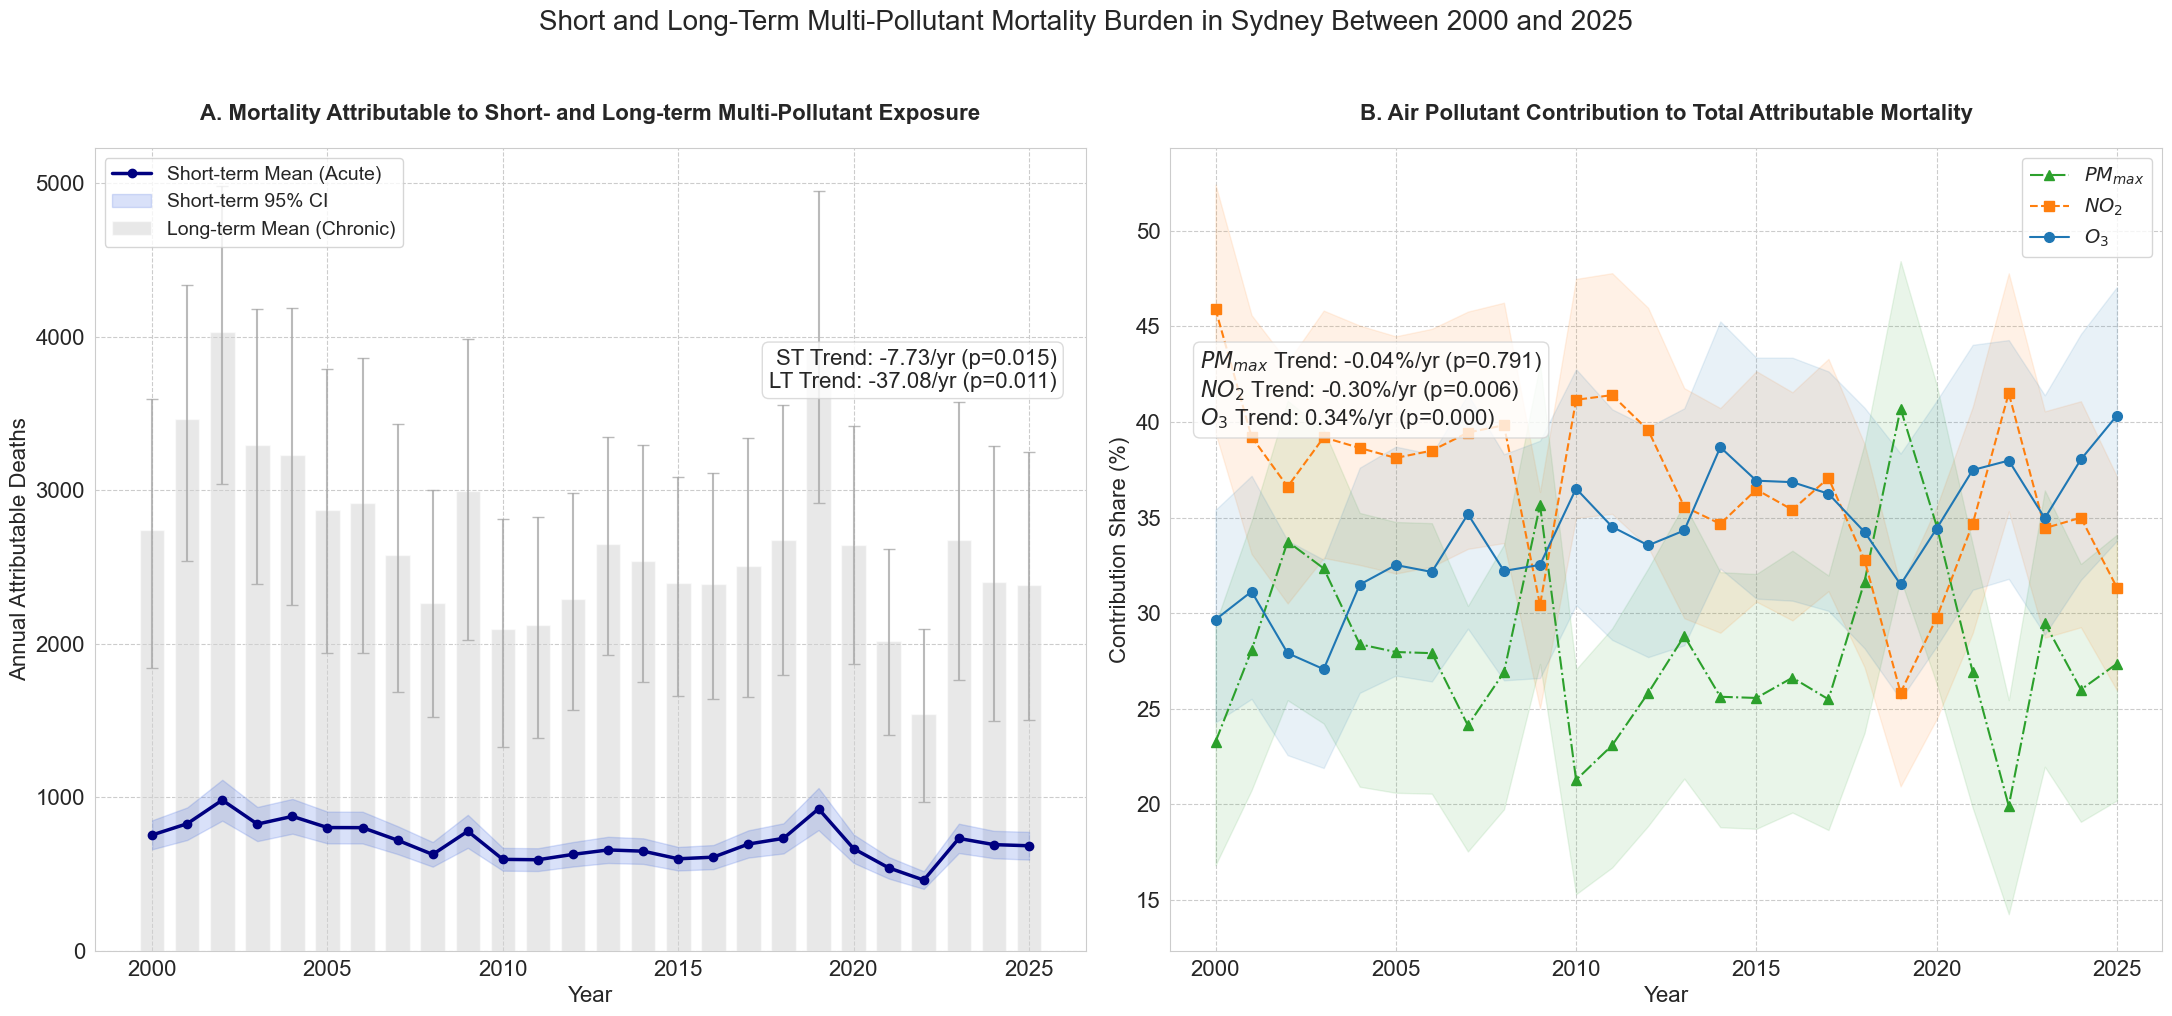

In [6]:
import seaborn as sns
import pymannkendall as mk
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ============================================================
# OUTPUT PATH — GitHub-ready
# ============================================================

PROJECT_ROOT = Path("..")
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

fig_file = FIGURES_DIR / "Short_Long_Term_MultiPollutant_Mortality_Burden_2000_2025.png"

sns.set_style("whitegrid", {'grid.linestyle': '--'})
plt.rcParams.update({'font.size': 16}) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# --- TREND ANALYSIS (Mann-Kendall) ---
mk_short = mk.original_test(short_mean)
mk_long = mk.original_test(long_mean)

# Calculate shares for Panel B
pm_share_mean = sim_short_pm.mean(axis=1) / sim_short_total.mean(axis=1) * 100
no2_share_mean = sim_short_no2.mean(axis=1) / sim_short_total.mean(axis=1) * 100
o3_share_mean = sim_short_o3.mean(axis=1) / sim_short_total.mean(axis=1) * 100

mk_pm = mk.original_test(pm_share_mean)
mk_no2 = mk.original_test(no2_share_mean)
mk_o3 = mk.original_test(o3_share_mean)

# --- Panel A: Mortality Attributable ---
ax1.bar(year_index, long_mean, color='lightgrey', alpha=0.5, label='Long-term Mean (Chronic)', width=0.7)
yerr_long = [long_mean - long_lcl, long_ucl - long_mean]
ax1.errorbar(year_index, long_mean, yerr=yerr_long, fmt='none', ecolor='darkgrey', capsize=4, alpha=0.8)

ax1.plot(year_index, short_mean, color='navy', lw=2.5, marker='o', markersize=6, label='Short-term Mean (Acute)')
ax1.fill_between(year_index, short_lcl, short_ucl, color='royalblue', alpha=0.2, label='Short-term 95% CI')

# Panel A Annotation
trend_text_a = (
    f"ST Trend: {mk_short.slope:.2f}/yr (p={mk_short.p:.3f})\n"
    f"LT Trend: {mk_long.slope:.2f}/yr (p={mk_long.p:.3f})"
)
ax1.text(0.97, 0.75, trend_text_a, transform=ax1.transAxes, fontsize=16,
         verticalalignment='top', horizontalalignment='right', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgrey'))

ax1.set_title("A. Mortality Attributable to Short- and Long-term Multi-Pollutant Exposure", fontsize=16, fontweight="bold", pad=20)
ax1.set_ylabel("Annual Attributable Deaths", fontsize=16)
ax1.set_xlabel("Year", fontsize=16)
ax1.legend(loc='upper left', fontsize=14, frameon=True)

# --- Panel B: Air Pollutant Contribution with Subscripts ---
with np.errstate(divide="ignore", invalid="ignore"):
    share_pm_sim = (sim_short_pm / sim_short_total) * 100
    share_no2_sim = (sim_short_no2 / sim_short_total) * 100
    share_o3_sim = (sim_short_o3 / sim_short_total) * 100

# PMmax - Using Subscript in label
ax2.plot(year_index, pm_share_mean, marker="^", linestyle="-.", color='tab:green', label="$PM_{max}$", markersize=7)
ax2.fill_between(year_index, np.nanpercentile(share_pm_sim, 2.5, axis=1), 
                 np.nanpercentile(share_pm_sim, 97.5, axis=1), color='tab:green', alpha=0.1)

# NO2 - Using Subscript in label
ax2.plot(year_index, no2_share_mean, marker="s", linestyle="--", color='tab:orange', label="$NO_2$", markersize=7)
ax2.fill_between(year_index, np.nanpercentile(share_no2_sim, 2.5, axis=1), 
                 np.nanpercentile(share_no2_sim, 97.5, axis=1), color='tab:orange', alpha=0.1)

# O3 - Using Subscript in label
ax2.plot(year_index, o3_share_mean, marker="o", color='tab:blue', label="$O_3$", markersize=7)
ax2.fill_between(year_index, np.nanpercentile(share_o3_sim, 2.5, axis=1), 
                 np.nanpercentile(share_o3_sim, 97.5, axis=1), color='tab:blue', alpha=0.1)

# Panel B Annotation with Subscripts
trend_text_b = (
    f"$PM_{{max}}$ Trend: {mk_pm.slope:.2f}%/yr (p={mk_pm.p:.3f})\n"
    f"$NO_2$ Trend: {mk_no2.slope:.2f}%/yr (p={mk_no2.p:.3f})\n"
    f"$O_3$ Trend: {mk_o3.slope:.2f}%/yr (p={mk_o3.p:.3f})"
)
ax2.text(0.03, 0.75, trend_text_b, transform=ax2.transAxes, fontsize=16,
         verticalalignment='top', horizontalalignment='left', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgrey'))

ax2.set_title("B. Air Pollutant Contribution to Total Attributable Mortality", fontsize=16, fontweight="bold", pad=20)
ax2.set_ylabel("Contribution Share (%)", fontsize=16)
ax2.set_xlabel("Year", fontsize=16)
ax2.legend(loc='upper right', fontsize=14, frameon=True)

# Tick font sizes
ax1.tick_params(axis='both', labelsize=16)
ax2.tick_params(axis='both', labelsize=16)

plt.suptitle("Short and Long-Term Multi-Pollutant Mortality Burden in Sydney Between 2000 and 2025", fontsize=20, y=1.02)
plt.tight_layout()

plt.savefig(fig_file, dpi=300, bbox_inches="tight")
plt.show()